# A5 CW Solutions: Fitting QNMs
### Joey Wee

- Let's start by examining and plotting the data.dat file.

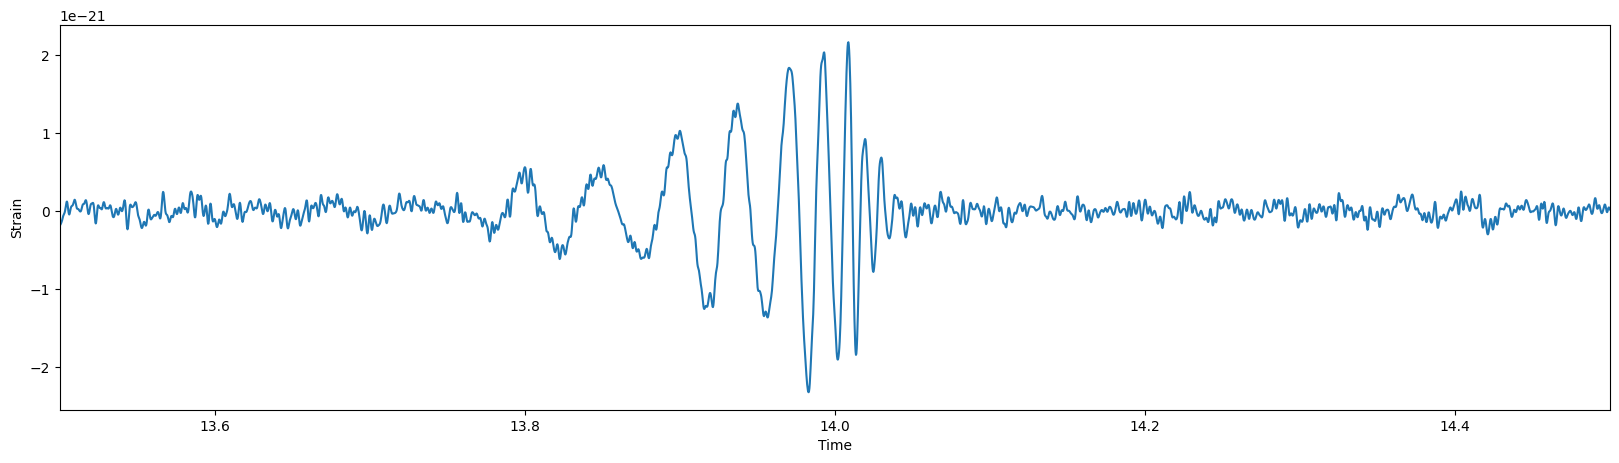

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat', skiprows=1)

fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(data[:,0], data[:,1])
ax.set_xlim(13.5,14.5)

t = data[:,0]
strain = data[:,1]


In [1]:
import qnm

# These are the some precomputed spin sequences
qnm.download_data()

Destination path C:\Users\Joey\.qnm\data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


- According to the no-hair theorem, any black hole can be described by the mass $M$ and the angular momentum $J = \chi M^2$, where $\chi$ is a dimensionless spin parameter $\chi \in [0,1[$ .

## Q1: Calculate the dimensionless frequencies
- Consider (l, m, n) = (2, 2, 0) and (3, 3, 0)
- Calculate the dimensionless frequencies $\hat{\omega}(M,\chi) = M\omega(\chi)$.
- Plot the real and imaginary parts of those frequencies.
    - The real part is the oscillatin' part.
    - The imaginary part causes the pertrubation to decay in time.


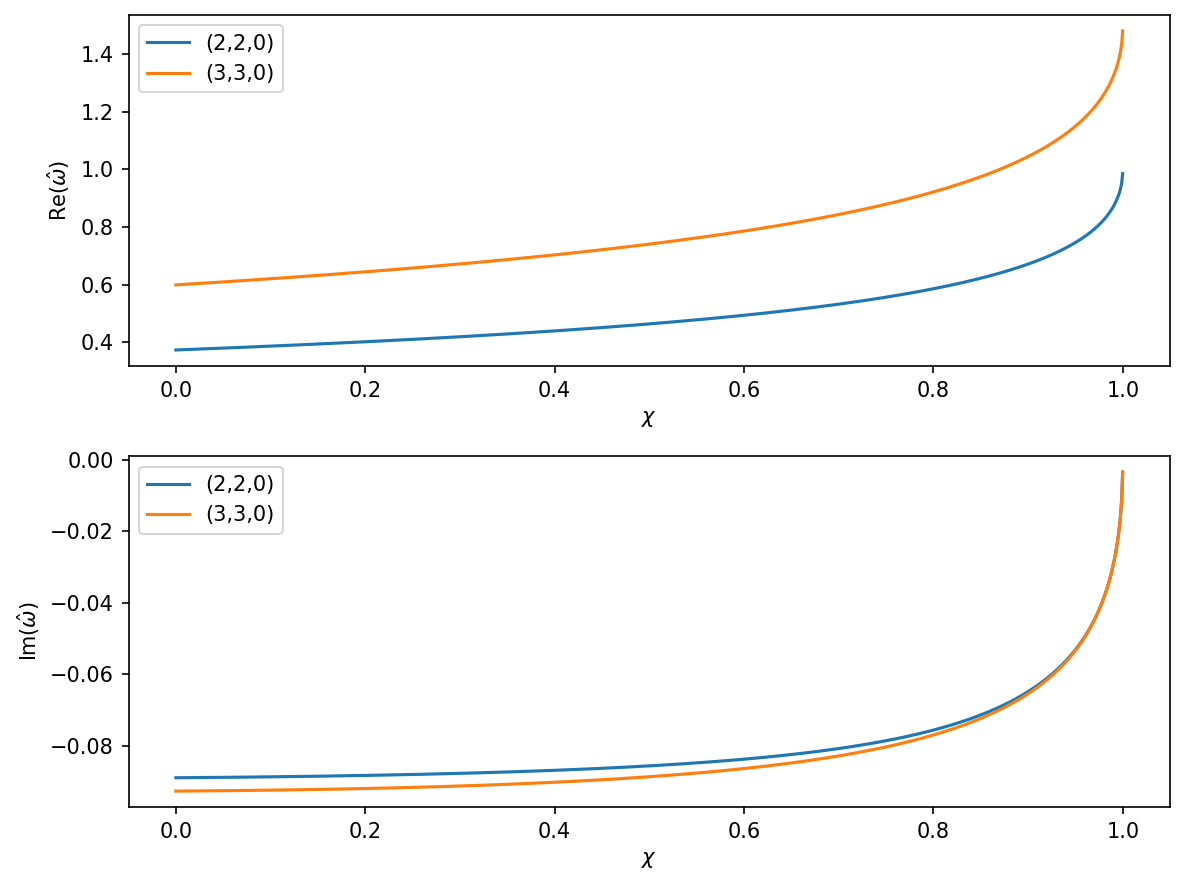

In [4]:
# The dense chi grid over which to calculate the dimensionless freqs
chi_values = np.linspace(0, 0.9999, 1000)

omega_220 = []
omega_330 = []

# Get mode objects
mode_220 = qnm.modes_cache(s=-2, l=2, m=2, n=0)
mode_330 = qnm.modes_cache(s=-2, l=3, m=3, n=0)

# Loop over chi values
for chi in chi_values:
    w220, _, _ = mode_220(chi)
    w330, _, _ = mode_330(chi)
    omega_220.append(w220)
    omega_330.append(w330)

# Convert to numpy arrays
omega_220 = np.array(omega_220)
omega_330 = np.array(omega_330)

# Now plot real and imaginary parts separately
fig, ax = plt.subplots(2, 1, figsize=(8, 6), dpi = 150)

ax[0].plot(chi_values, omega_220.real, label='(2,2,0)')
ax[0].plot(chi_values, omega_330.real, label='(3,3,0)')
ax[0].set_ylabel(r'$\mathrm{Re}(\hat{\omega})$')
ax[0].set_xlabel(r'$\chi$')
ax[0].legend()

ax[1].plot(chi_values, omega_220.imag, label='(2,2,0)')
ax[1].plot(chi_values, omega_330.imag, label='(3,3,0)')
ax[1].set_ylabel(r'$\mathrm{Im}(\hat{\omega})$')
ax[1].set_xlabel(r'$\chi$')
ax[1].legend()

plt.tight_layout()
plt.show()

## Q2: Splitting Data
- The data has off and on-source regimes corresponding to where there is and isn't any black hole merger signal.
- There is also a ringdown start time $t_0$ that corresponds.
- The off/on-signal bounds are loose bounds and it is not significant if there is some off-signal portion in the on-signal part.
- However, if there is on-signal data in the off-signal portion it will affect the off-signal analysis significantly.
----
- We start by examining the off/on-signal times. 
- Since this is a loose bound, we can do the identification by eye.
- We can better visualise the data by plotting a spectrogram.

#### Spectrogram

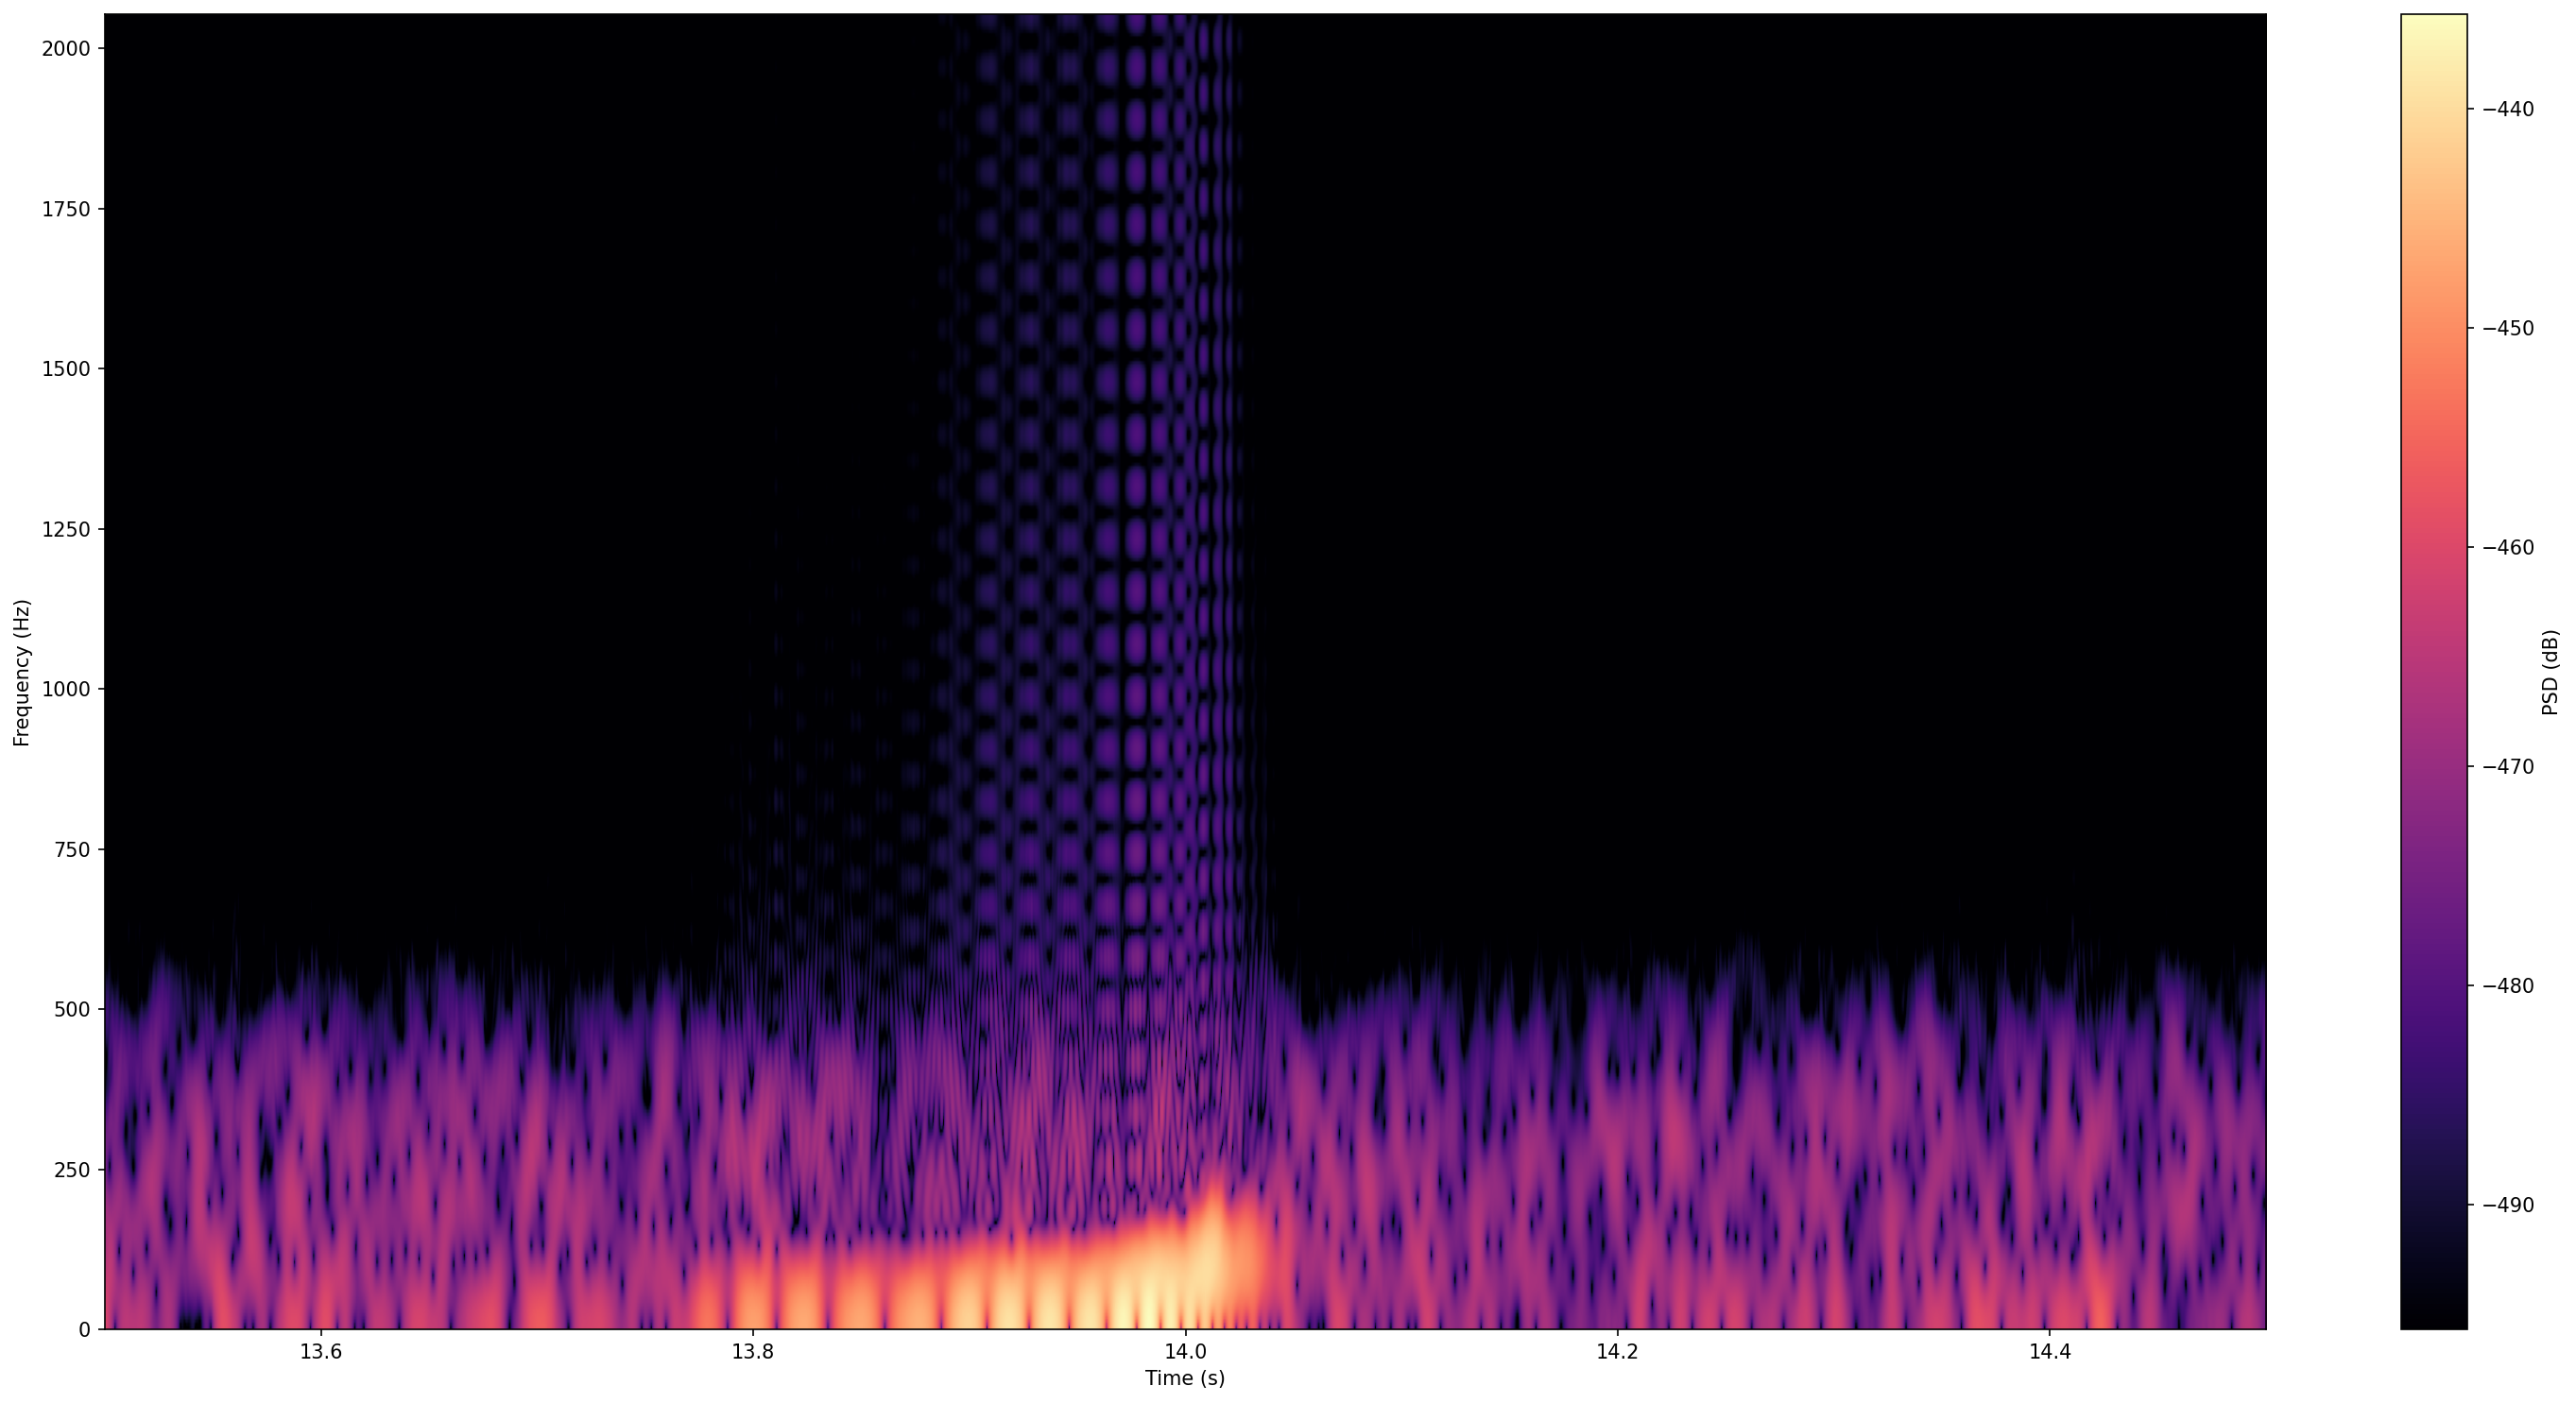

In [5]:
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import gaussian


# 32 seconds of data at 4096 Hz 
T_x = 1/4096 # Time between samples
N = len(t) # Number of samples

# Time indices for the signal
t_x = np.arange(N) * T_x # N time ppoints spanning across N*T_x seconds

# Use Gaussian weighted windows to prevent spectral leakage
g_std = 12 # Width of Gaussian window
win  = gaussian(50, std=g_std, sym=True)
SFT = ShortTimeFFT(win, hop=2, fs=1/T_x, mfft=800, scale_to='psd')
Sx2 = SFT.spectrogram(strain) # Magnitude squared "x2"

# Convert into decibels for interpretability
Sx_dB = 10 * np.log10(np.fmax(Sx2, Sx2.max() * 1e-6))

# Plot the spectrogram
fig, ax = plt.subplots(figsize= (20,10), dpi=150)
t_lo, t_hi = SFT.extent(N)[:2] # Slightly wider time range because of the windows
ax.set_xlim(13.5,14.5) # Only look at the region around the on-period
im = ax.imshow(Sx_dB, origin='lower', aspect='auto', extent=SFT.extent(N), cmap='magma')
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)')
fig.colorbar(im, label='PSD (dB)')
fig.tight_layout()
plt.show()

In [7]:
on_time_start = 13.7
on_time_end = 14.1

- We can see here that, compared to the background, 13.8 to 14.0 is different.
- To make sure there is no on-signal time in the off-signal data, the bounds are extended by 100ms in each direction.
- This agrees with the strain vs time plot well (see below).

----
- Quasinormal modes decay in $t$. 
- It logically follows that at any time after the start time $t_0$, the signal will be weaker than at $t_0$. So, a starting estimate of $t_0$ will be time time of the peak amplitude of the strain.
- We can use a Hilbert transform the signal to get the amplitude term.
- We take the peak of this amplitude to be the start of our ringdown time $t_0$.
- If the $t_0$ is too early, the merger data will pollute the QNM fitting.
- If the $t_0$ is later, the fit will only have to contend with less signal-to-noise.
- The latter regime is less serious so we add 25 milliseconds to the Hilbert peak.

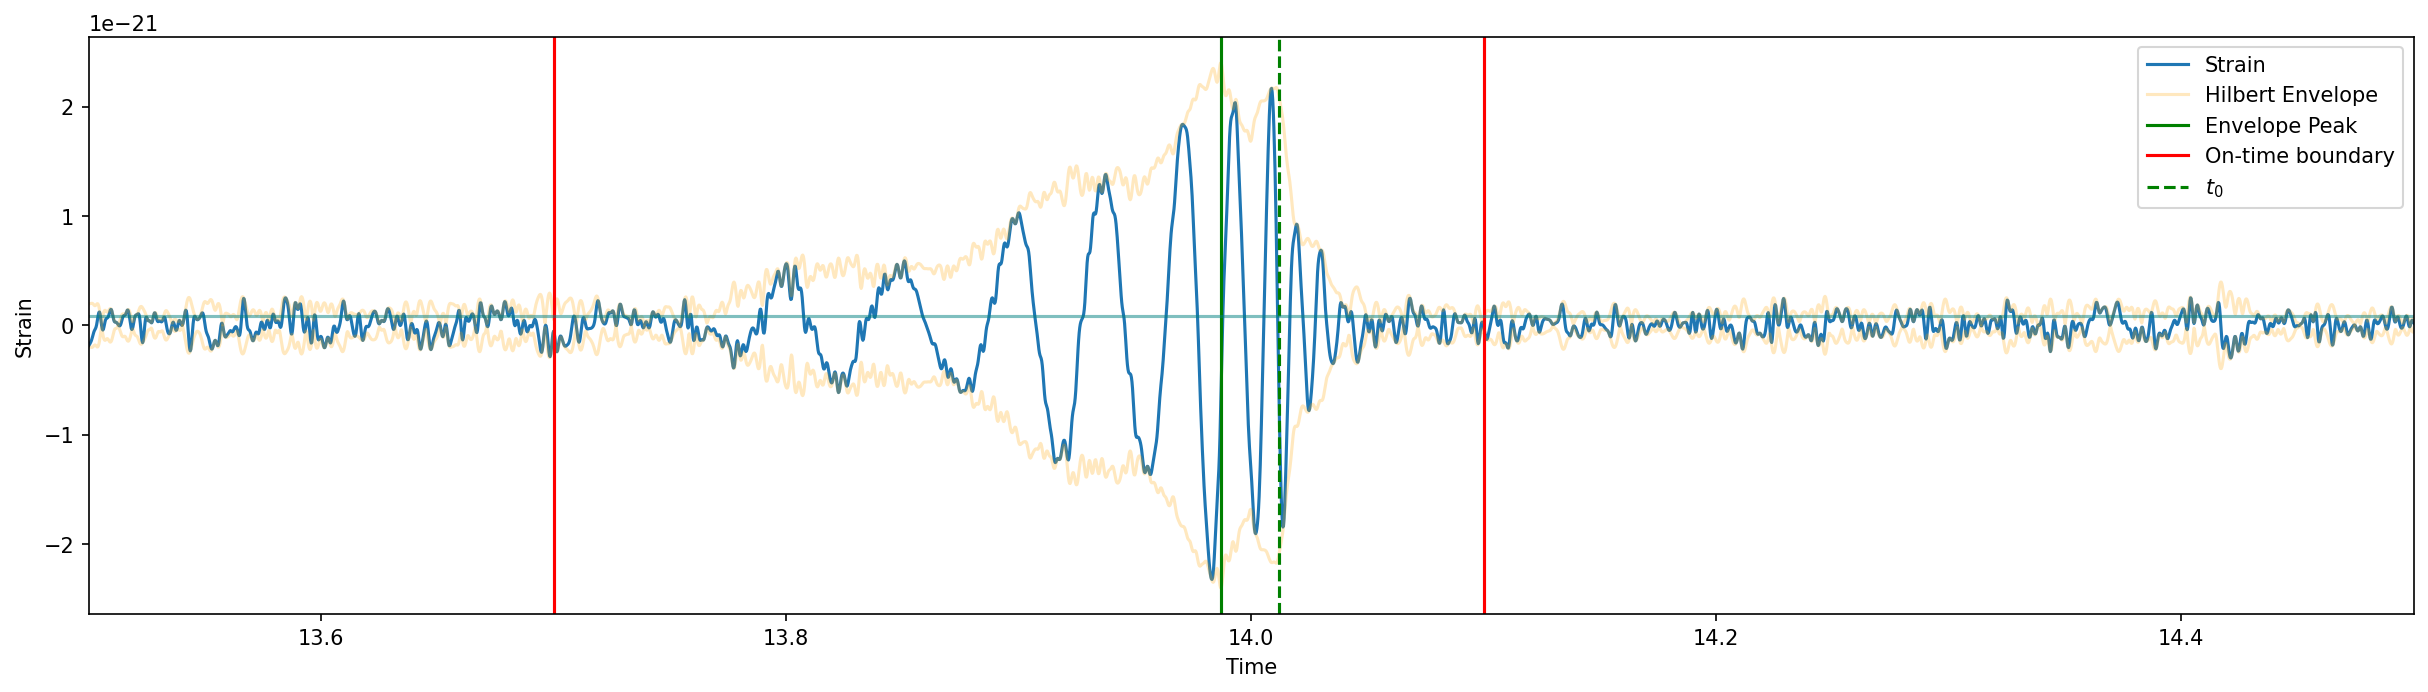

In [8]:
from scipy.signal import hilbert

# Hilbert transform
analytic = hilbert(strain)
envelope = np.abs(analytic)

# Initial t0 estimate
t0 = t[np.argmax(envelope)]

# Plot
fig, ax = plt.subplots(figsize = (20,5), dpi=150)
ax.set_xlabel("Time")
ax.set_ylabel("Strain")
ax.plot(t, strain, label='Strain')
ax.plot(t, envelope, alpha=0.25, label='Hilbert Envelope', color='orange')
ax.plot(t, -envelope, alpha=0.25, color='orange')
ax.axvline(t0, color='green', label='Envelope Peak')
ax.axvline(on_time_start, color='red', label='On-time boundary')
ax.axvline(on_time_end, color='red')
ax.axvline(t0+0.025, color='green', linestyle='dashed', label='$t_0$')
ax.axhline(8.32e-23, color='teal', alpha=0.5)
ax.set_xlim(13.5,14.5)
ax.legend()

In [9]:
t0_old = t0
t0 = t0+0.025 # The 25 millisecond buffer

## Q3: Estimate the $\sigma$
- We are desirous of using a white noise likelihood for inference of our parameters.$$log \mathcal{L}_{\mathrm{WN}}(d \mid \theta) = -\frac{1}{2} \sum_i \frac{\bigl(d(t_i)-h(t_i;\theta)\bigr)^2}{\sigma^2} .$$
- To do so, the white noise must be parameterised by $\sigma$.
- We can estimate $\sigma$ by taking the standard deviation of the off-source data as this should just be noise.

In [13]:
off_strain = strain[(t < on_time_start) | (t > on_time_end)] # The strains of the off-periods
off_std = np.std(off_strain)

print(f"Off standard deviation = {off_std:.4e}")

Off standard deviation = 8.3243e-23


In [10]:
# Creating datasets for later analysis

# On-period
t_on = t[(t > on_time_start) & (t < on_time_end)]
d_on = strain[(t > on_time_start) & (t < on_time_end)]

# First off-period
t_off_1 = t[(t < on_time_start)]
d_off_1 = strain[(t < on_time_start)]

# Second off-period
t_off_2 = t[(t > on_time_end)]
d_off_2 = strain[(t > on_time_end)]

# The ringdown period
t_ring = t_on[t_on > t0]
d_ring = d_on[t_on > t0]

## Q4: Sample parameters
- We will use a dynesty nested sampler.
- Priors:
    - Amplitudes: 
        - Log-uniform prior on $[10^{-25}, 10^{-20}]$.
        - These are bounded by peak strain ($\sim 10^{-21}$) and some arbitrary low detection limit.
    - Phases:
        - Uniform prior on $[-\pi, \pi]$.
        - Standard cyclic prior for phase parameters.
    - Frequencies:
        - Log-uniform prior on $[20 \text{ Hz}, 400 \text{ Hz}]$.
        - Bounds defined by parameters of the bandpass filter.
    - Decay timescales: 
        - Log-uniform prior on $[0.1 \text{ ms}, 100 \text{ ms}]$.
        - Lower bound: One sample duration is 0.24 ms. To be conservative, this was rounded to 0.1ms.
        - Upper bound: Literature-motivated upper limit.


In [14]:
# White noise likelihood
def lnL(theta):
    A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
    t = t_ring
    model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
    residuals = d_ring - model  
    return -0.5 * np.sum(residuals**2 / off_std**2)

# Dynesty needs a function to turn uniform random numbers to positions for prior
def prior_transform(u):
    A1_u, phi1_u, f1_u, tau1_u, A2_u, phi2_u, f2_u, tau2_u = u

    # log-uniform on amplitudes 
    A_min, A_max = 1e-25, 1e-20
    A1   = A_min * (A_max / A_min) ** A1_u
    A2   = A_min * (A_max / A_min) ** A2_u

    # uniform on phases [-pi, pi]
    phi1 = -np.pi + phi1_u * 2 * np.pi
    phi2 = -np.pi + phi2_u * 2 * np.pi

    # log-uniform on frequencies 
    # f_min, f_max = 20.0, 4096.0 
    f_min, f_max = 20.0, 400
    f1   = f_min * (f_max / f_min) ** f1_u
    f2   = f_min * (f_max / f_min) ** f2_u

    # log-uniform on damping times 
    tau_min, tau_max = 1e-4, 1e-1
    tau1 = tau_min * (tau_max / tau_min) ** tau1_u
    tau2 = tau_min * (tau_max / tau_min) ** tau2_u

    return [A1, phi1, f1, tau1, A2, phi2, f2, tau2]

In [ ]:
import dynesty

# I know you have never seen Star Trek so I will cite the movie reference.
np.random.seed(1701) # [1]

sampler = dynesty.DynamicNestedSampler(
    lnL,
    prior_transform,
    ndim=8,
    bound='multi',    # multiellipsoid bounding
    sample='rwalk'    # random walk sampling
)

sampler.run_nested(print_progress=True)

# Bibliography
# [1] All of Star Trek.

28005it [03:01, 153.94it/s, batch: 4 | bound: 6 | nc: 1 | ncall: 724364 | eff(%):  3.795 | loglstar: -185.830 < -178.796 < -180.391 | logz: -216.060 +/-  0.203 | stop:  0.927]          


In [16]:
from dynesty import utils as dyfunc

results = sampler.results

# Dynesty samples are not equally weighted. Reweight them.
weights = np.exp(results.logwt - results.logz[-1])
samples = dyfunc.resample_equal(results.samples, weights)

# samples has shape (N, 8)
A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

- Now we plot all the the full posterior to check for convergence.

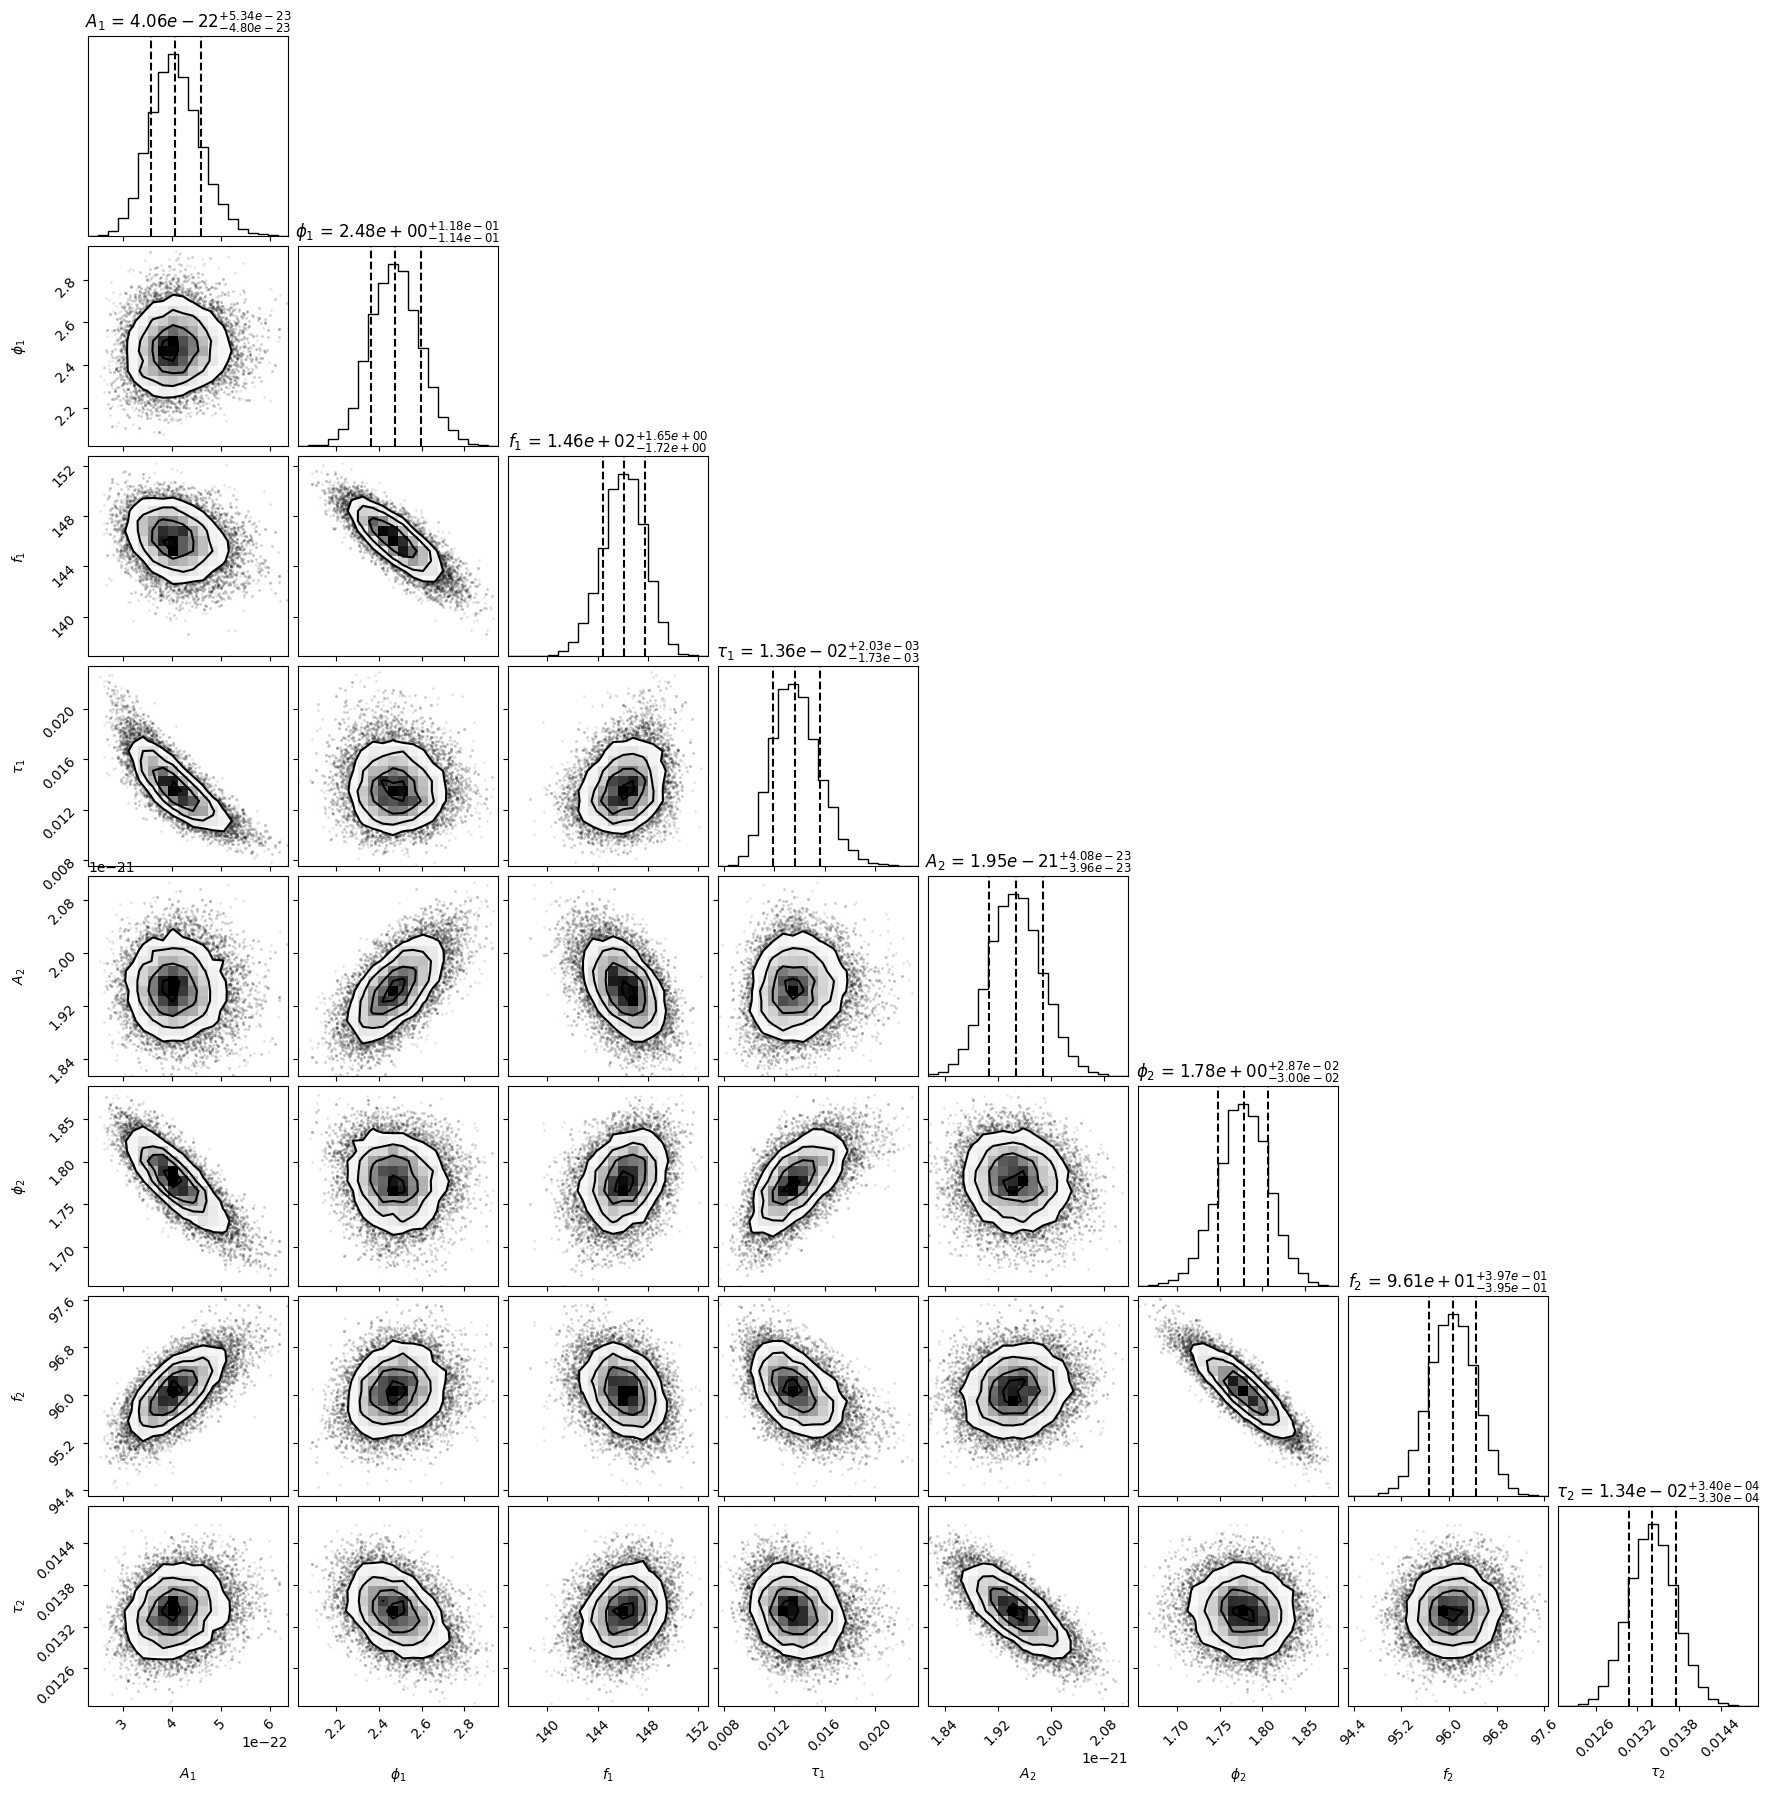

In [17]:
import corner

labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
          r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

fig = corner.corner(
    samples,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
)

- Plotting this, we can see that all the marginals are nice and Gaussian.
- They do not look like the priors at all: this is a likelihood-dominated regime.

---
- Plotting just $f$ and $\tau$ as required.

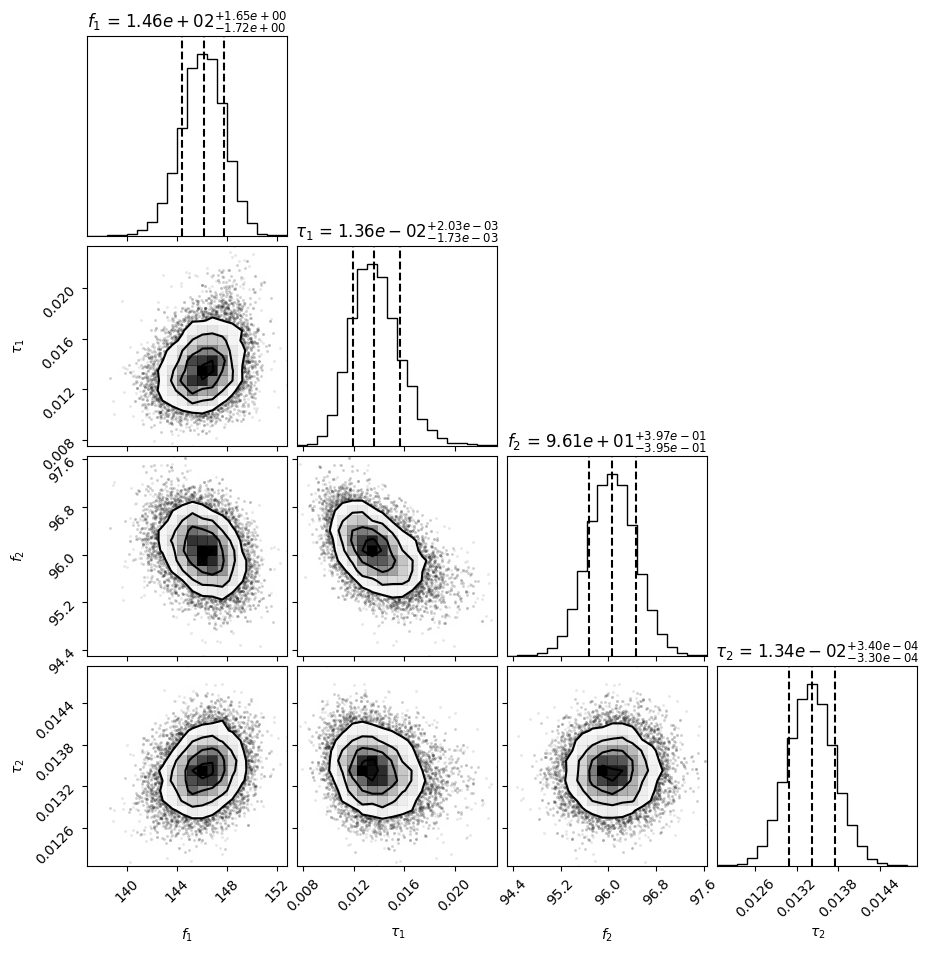

In [18]:
labels =  [r"$f_1$", r"$\tau_1$",
            r"$f_2$", r"$\tau_2$"]

samples_subset = samples[:, [2, 3, 6, 7]] # extract f and tau columns

fig = corner.corner(
    samples_subset,
    labels=labels,
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
    show_titles=True,
    title_fmt=".2e",
    dpi=150
)

- We can further verify the fits by plotting the posterior of the ringdown and the concomitant residuals.

Text(0.5, 0, 'Time')

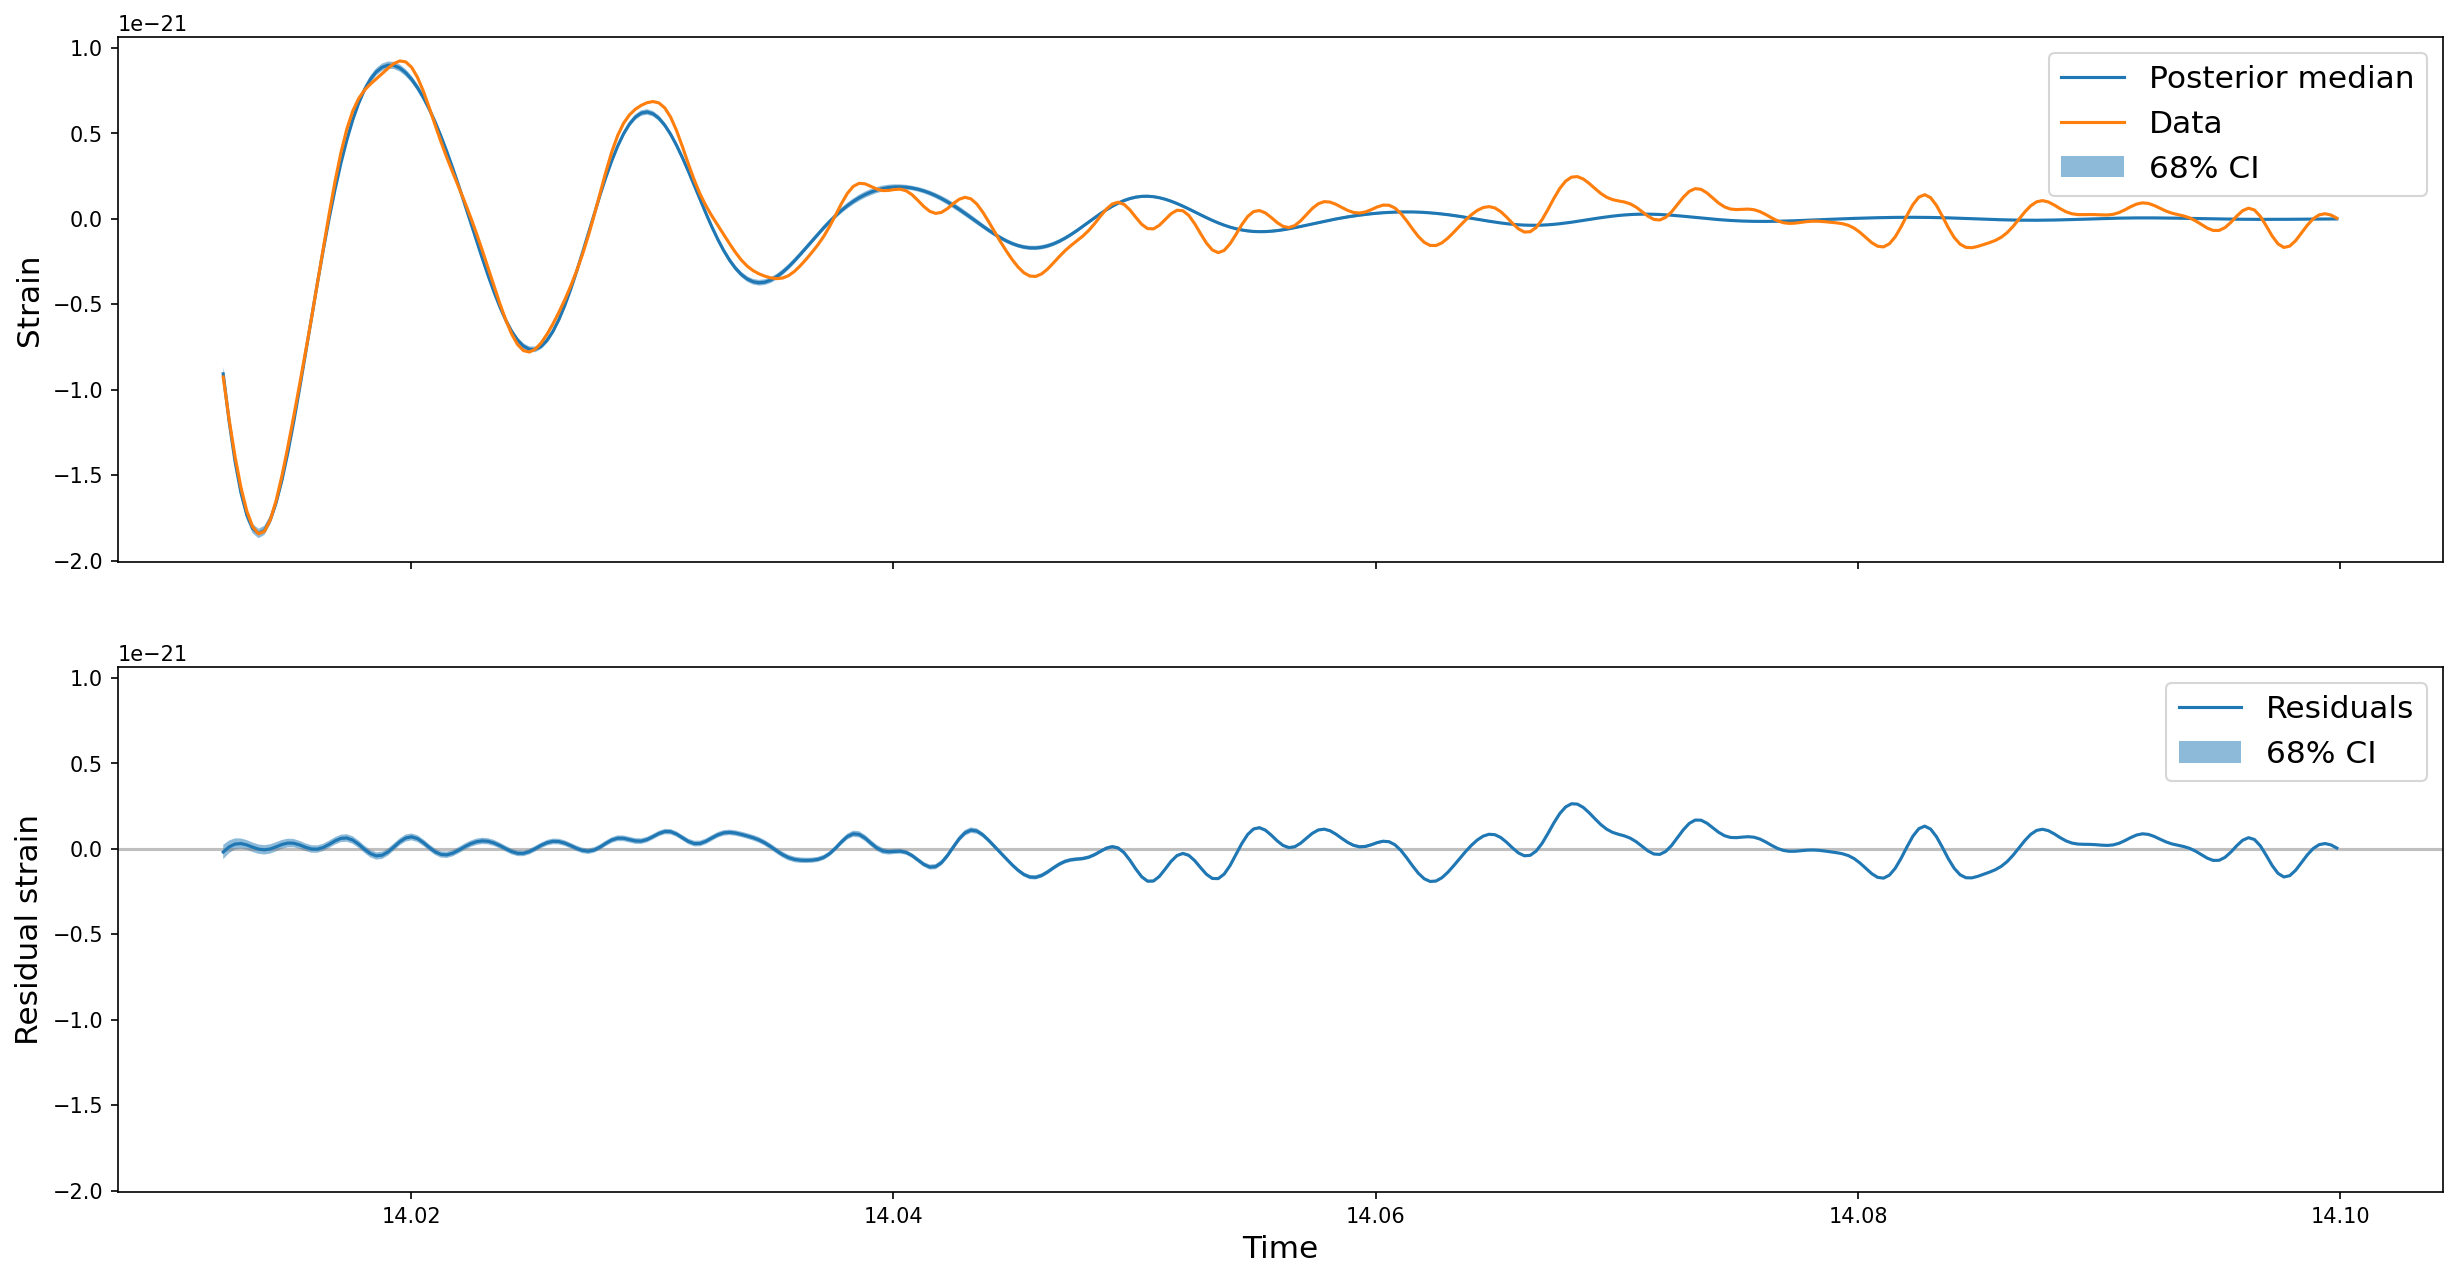

In [19]:
preds = []
# for sample in samples[:1000,:]:
for sample in samples: 
    # sample is in (N_params,)
    A1, phi1, f1, tau1 = sample[0], sample[1], sample[2], sample[3]
    A2, phi2, f2, tau2 = sample[4], sample[5], sample[6], sample[7]
    pred = (A1 * np.cos(2*np.pi*f1*(t_ring - t0) + phi1) * np.exp(-(t_ring - t0)/tau1) +
             A2 * np.cos(2*np.pi*f2*(t_ring - t0) + phi2) * np.exp(-(t_ring - t0)/tau2))
    preds.append(pred)

# Take the mean and 1std CI
pred_16 = np.percentile(preds, 16, axis=0)
pred_50 = np.percentile(preds, 50, axis=0)
pred_84 = np.percentile(preds, 84, axis=0)

# Take the residuals
resid_50 = d_ring - pred_50
resid_16 = d_ring - pred_16
resid_84 = d_ring - pred_84

# Plot
fig, ax = plt.subplots(2,1,figsize=(20,10), sharey=True, sharex=True, dpi=150)
ax[0].plot(t_ring, pred_50, label='Posterior median')
ax[0].plot(t_ring, d_ring, label='Data')
ax[0].fill_between(t_ring, pred_84, pred_16, alpha=0.5, label='68% CI')
ax[0].legend(fontsize=15)
ax[0].set_ylabel("Strain",fontsize=15)

ax[1].axhline(0, alpha=0.5, color='grey')
ax[1].plot(t_ring, resid_50, label='Residuals')
ax[1].fill_between(t_ring, resid_84, resid_16, alpha=0.5, label='68% CI')
ax[1].legend(fontsize=15)
ax[1].set_ylabel("Residual strain",fontsize=15)
ax[1].set_xlabel("Time",fontsize=15)


- This is good performance. The residuals grow a little over time but that is because towards the end of the ringdown period we are dominated by noise so this is irreducible.

## Q5: Off-source PSD
- The problem is that the concatenation of the two off-source sections would lead to signal bleed.
- I will take a PSD for each and then average them.

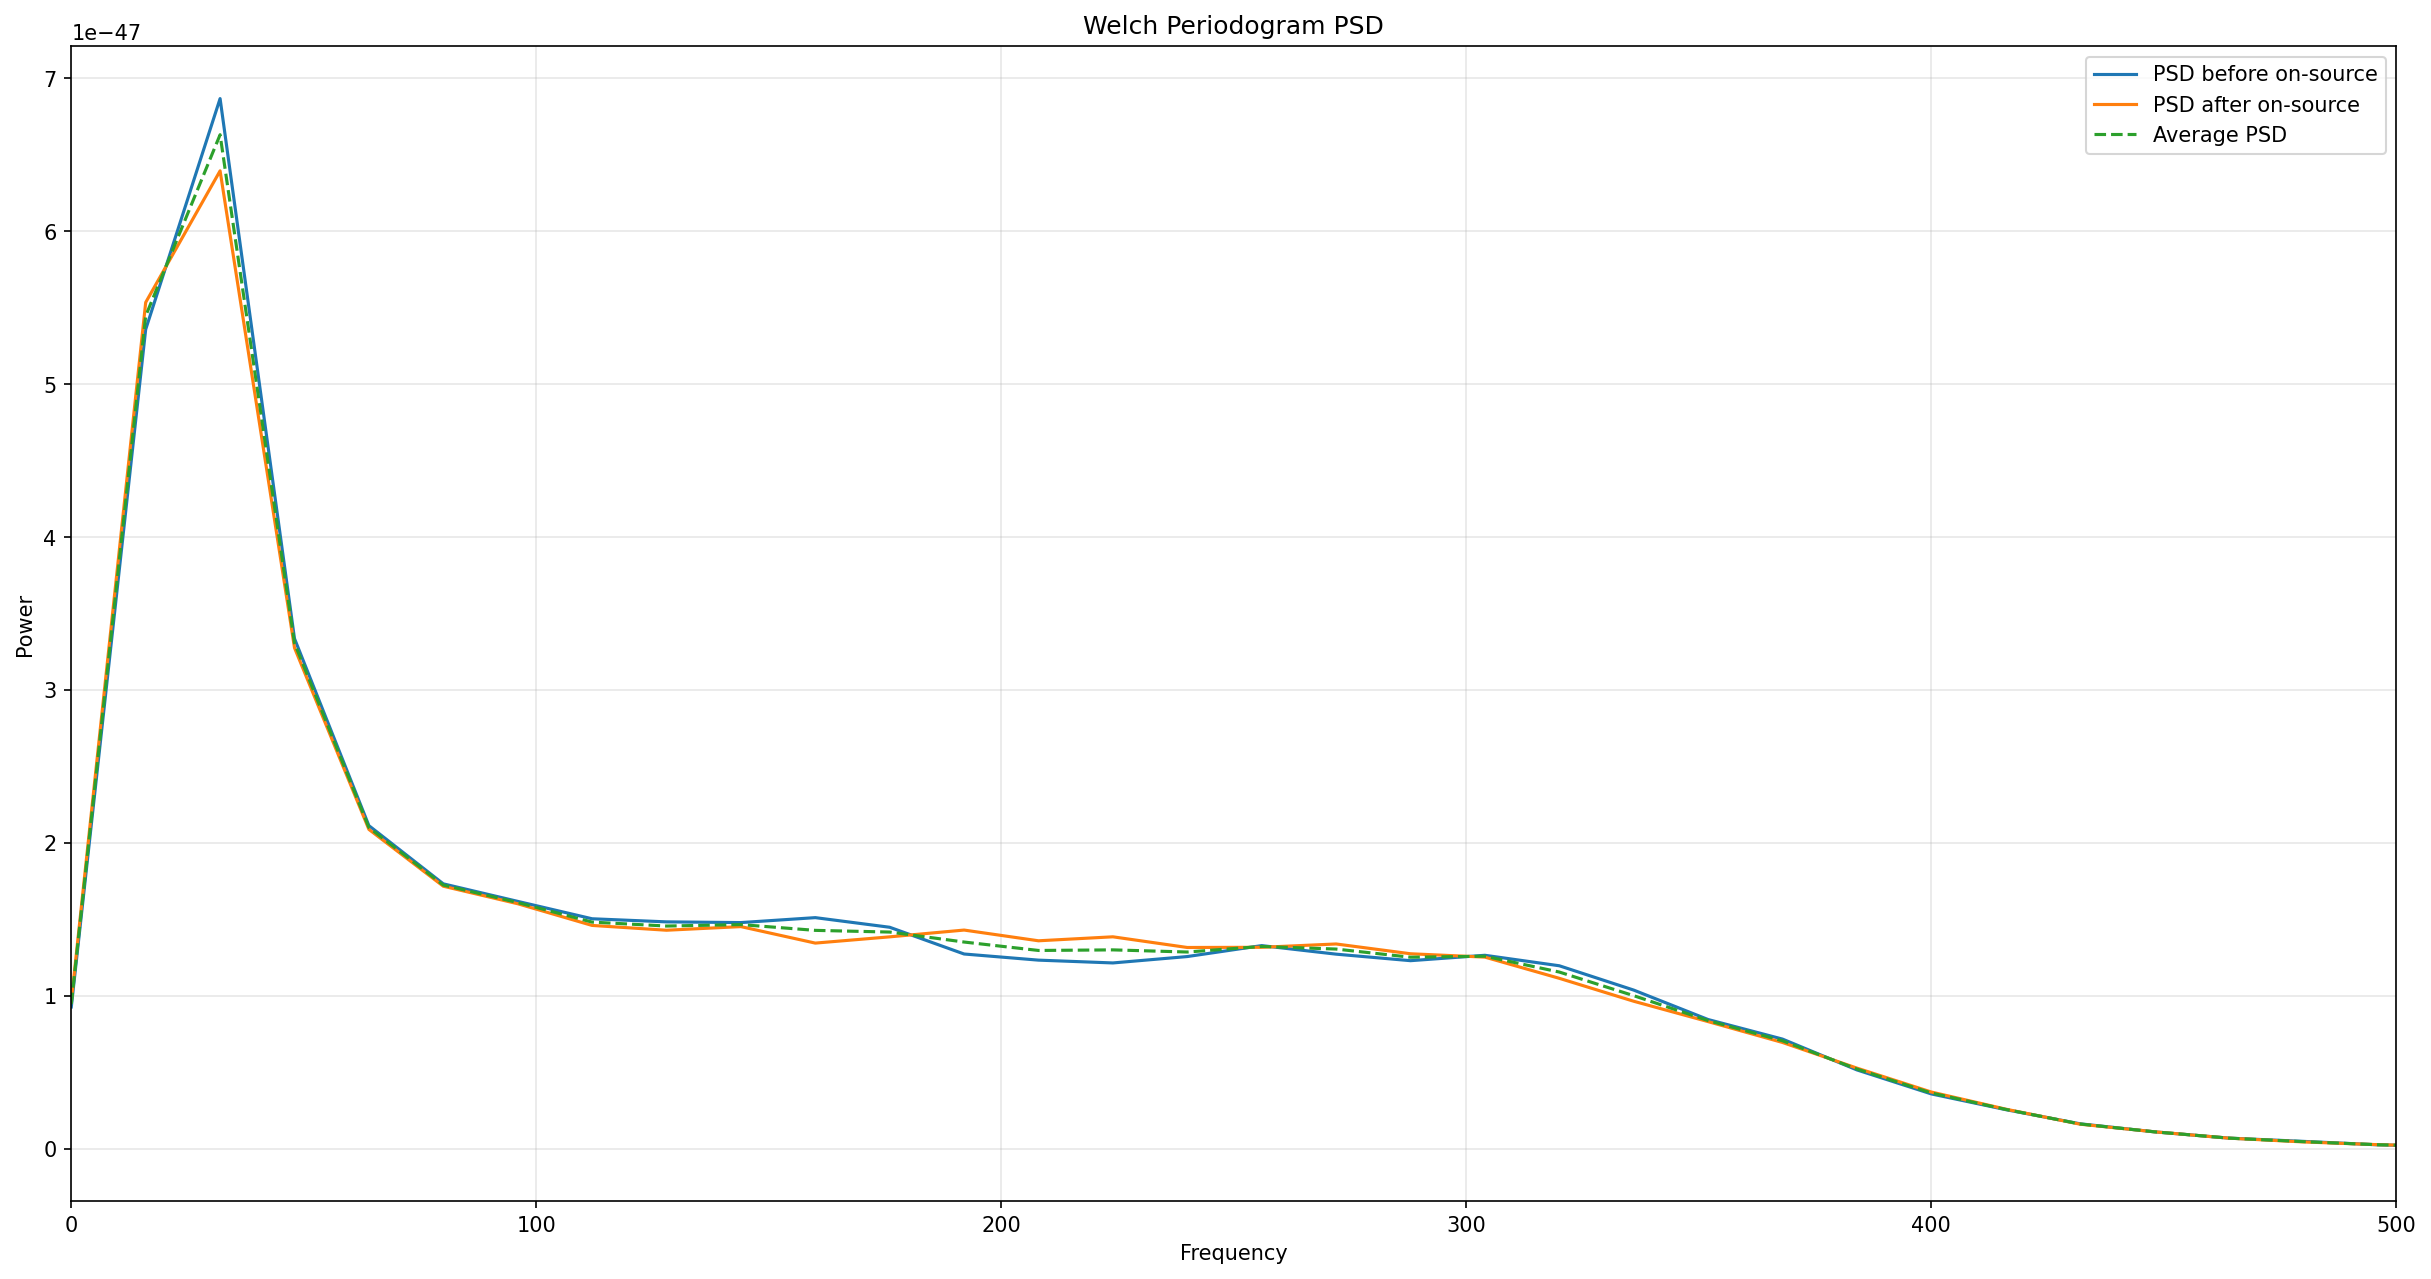

In [21]:
# Calculating a Welch periodogram for each
from scipy.signal import welch

fs = 4096
f_1, PSD_1 = welch(d_off_1, fs=fs, nperseg=256, noverlap=128, window='hann')
f_2, PSD_2 = welch(d_off_2, fs=fs, nperseg=256, noverlap=128, window='hann')
PSD_mean = np.mean([PSD_1, PSD_2], axis=0)

# Plot
fig, ax = plt.subplots(figsize = (20,10), dpi=150)
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(f_1, PSD_1, label='PSD before on-source')
ax.plot(f_2, PSD_2, label='PSD after on-source')
ax.plot(f_1, PSD_mean, linestyle='dashed', alpha=1,label='Average PSD')
ax.set_title("Welch Periodogram PSD")
ax.set_xlim(0,500)
ax.grid(True, alpha=0.3)
ax.legend()

- They both line up well. 
- This implies that both off-periods are uncontaminated by on-period data.
- We will use the mean going forwards.

- Let's examine the instrument noise PSD.

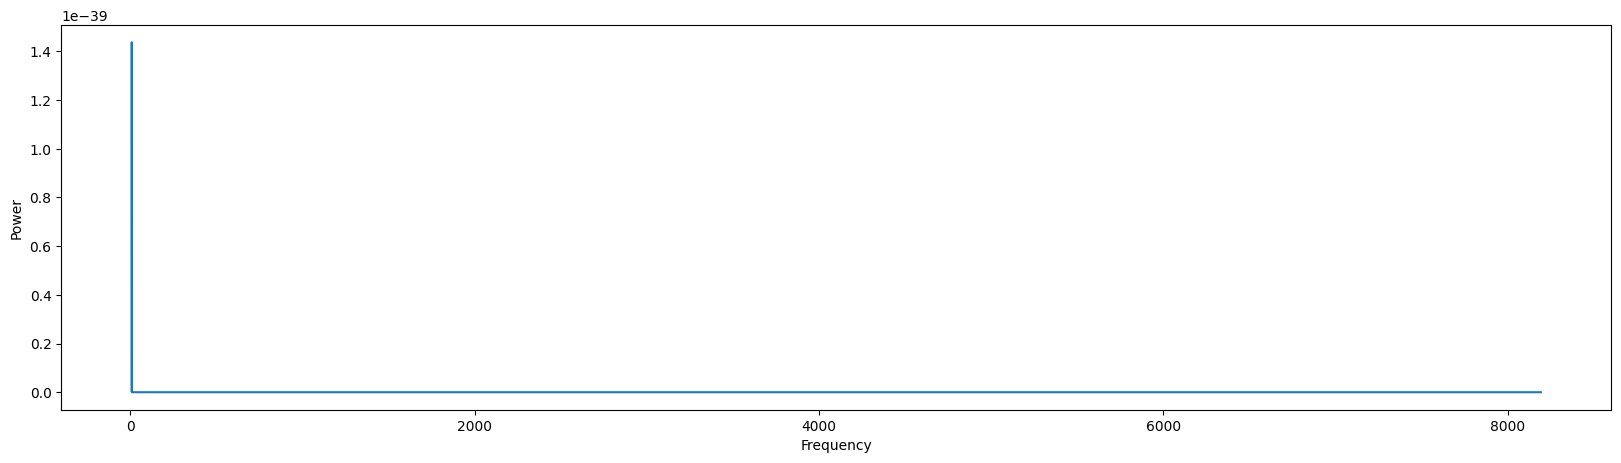

In [12]:
instrument_PSD = np.loadtxt('psd.dat', skiprows=1)
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")
ax.plot(instrument_PSD[:,0], instrument_PSD[:,1])


- These should be estimates of the same thing.
- Rescale them to plot together.

(0.0, 1000.0)

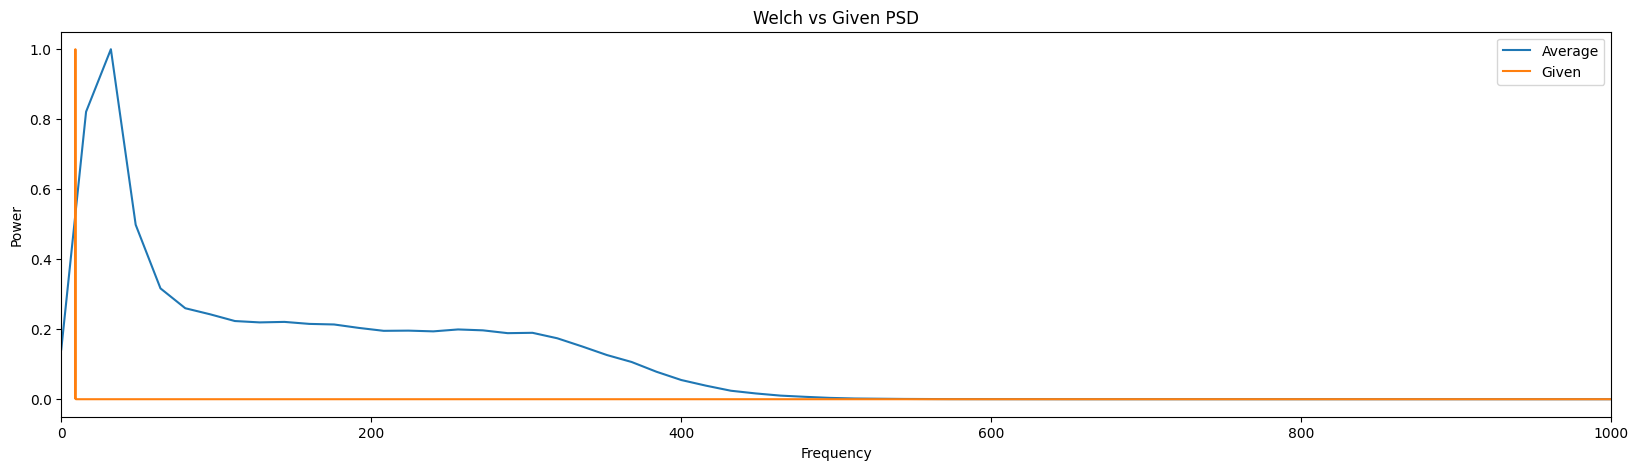

In [13]:
fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Frequency")
ax.set_ylabel("Power")

PSD_mean_rescaled = PSD_mean / max(PSD_mean)
PSD_instrument_rescaled = instrument_PSD[:,1] / max(instrument_PSD[:,1])

ax.plot(f_1, PSD_mean_rescaled, label='Average')
ax.plot(instrument_PSD[:,0], PSD_instrument_rescaled, label="Given")
ax.set_title("Welch vs Given PSD")
ax.legend()
ax.set_xlim(0,1000)


- Either way, neither of these is white-noise. White noise would have a constant power across all frequencies but this has a significan peak.
- I have it on good authority, by email, that as long as the waveforms being compared are narrow in frequency, such as the Lorentzian frequency bands of the QNMs, white noise is a good approximation.

## Q6: Calculate TDACF 
- If the white noise likelihood holds, the TDACF should be concentrates at 0 (subsequent points are uncorrelated).
- ACF and PSD are FFT pair according to the Wiener-Kinchin theorem.

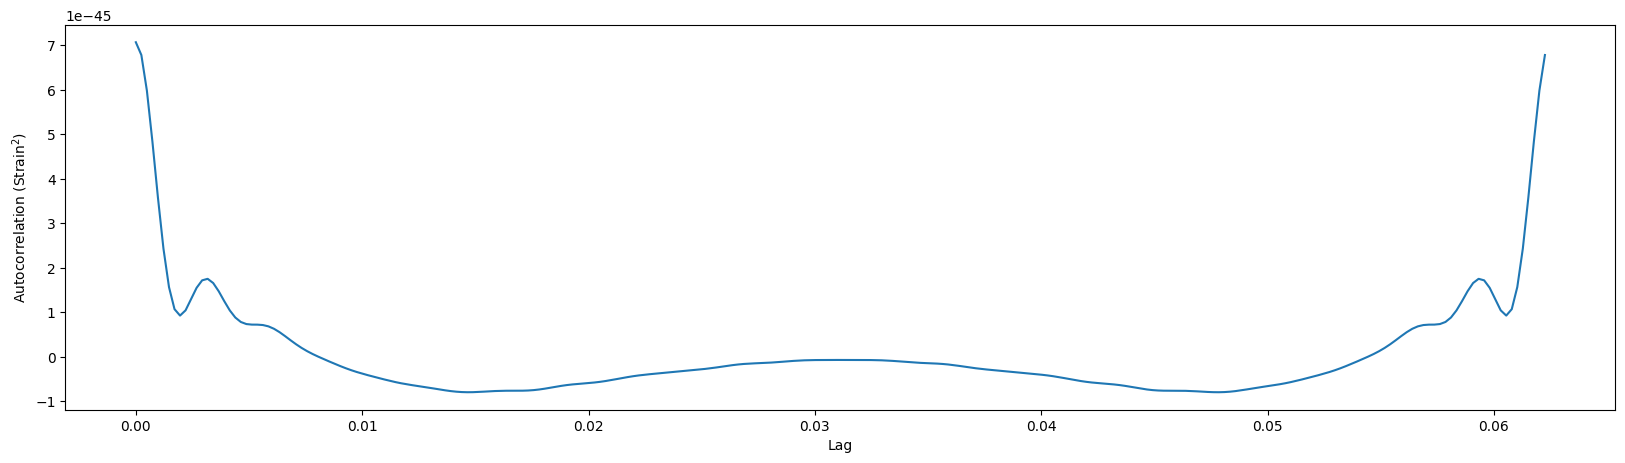

In [24]:
df = f_1[1] - f_1[0]  # sampling interval
N = 2 * (len(PSD_mean) - 1)

N_data = len(PSD_1) + len(PSD_2)# Len of the data
c95 = 1.96 / np.sqrt(N_data) # This is used for calculating the 95 percent CI

C = np.fft.irfft(PSD_mean) * df * N / 2   # units of strain squared
tau = np.arange(N) * (1 / (N * df))  # lag axis in seconds


fig, ax = plt.subplots(figsize = (20,5))
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation (Strain$^2$)")
ax.plot(tau, C)

- This has two lobes because the IRFFT calculates positive and negative lags cyclically.
- Let's plot the first half.

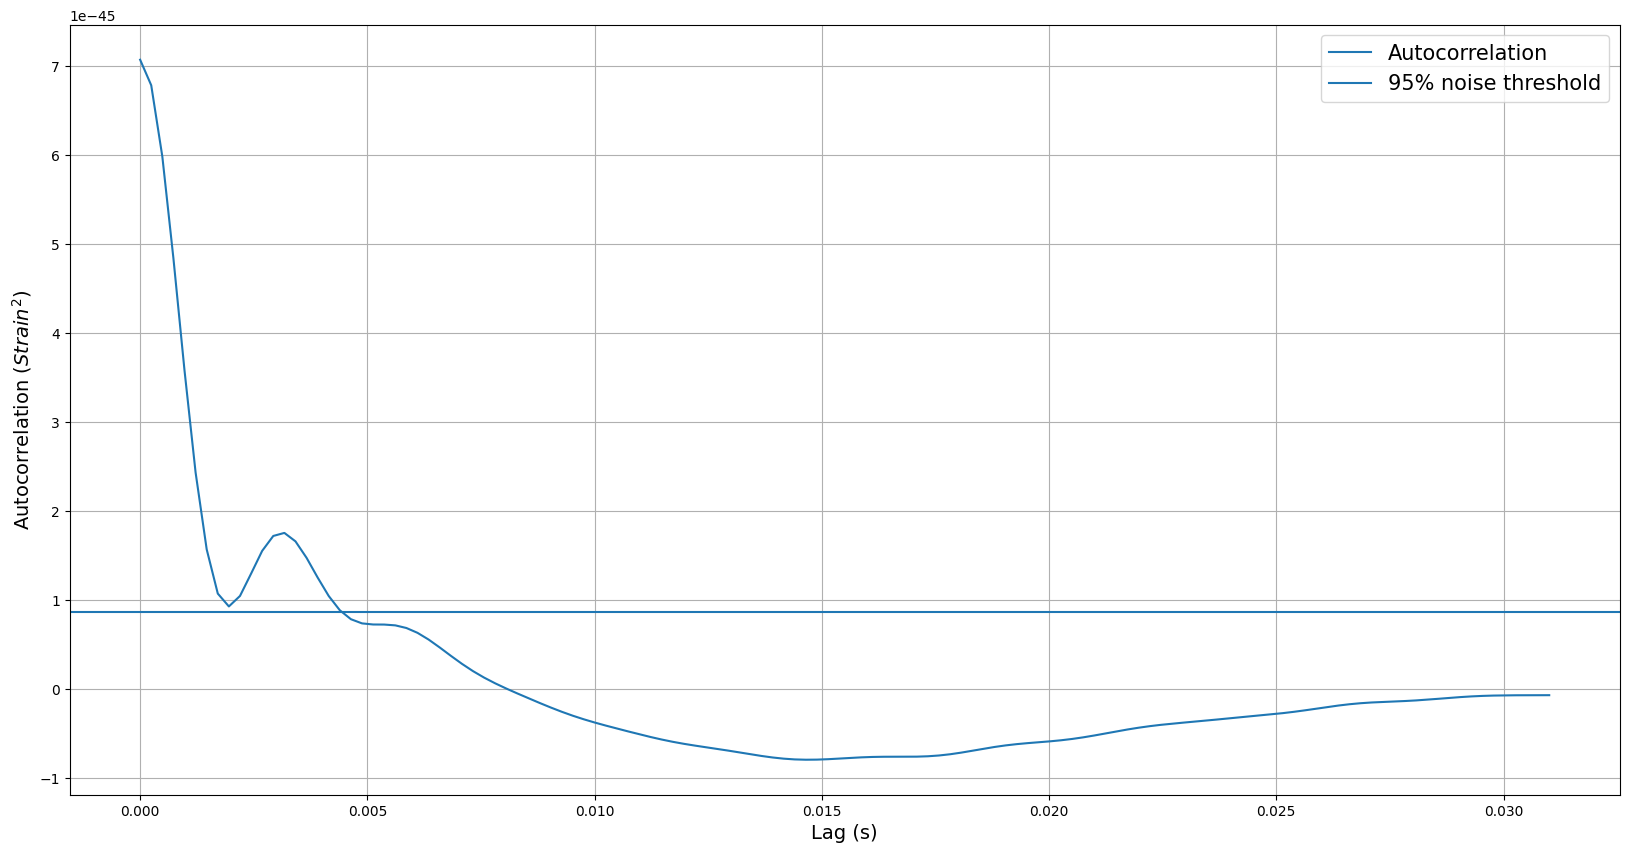

In [25]:
fig, ax = plt.subplots(figsize = (20,10))

ax.set_xlabel("Lag (s)", fontsize=14)
ax.set_ylabel("Autocorrelation ($Strain^2$)", fontsize=14)

ax.grid()

scaled_c95 =c95 * C[0]

N = len(tau)
ax.plot(tau[:N//2], C[:N//2], label='Autocorrelation')
ax.axhline(scaled_c95, label='95% noise threshold')

ax.legend(fontsize=15)

- The peak at low lags looks somewhat like what we would expect from white noise.
- Some of the width of that low-frequency peak can be attributed to the slight correlating effect of a Butterworth filter.
- There is a peak that sits above the noise that is above the 95% confidence for noise so there is probably some other effect in the data.
- The tau = 0 lag is dominant though so I think the white noise kernel is still applicable.

## Q7: Relating off_std to the ACF


In [26]:
rel = (C[0] - (off_std ** 2)) / (off_std ** 2)
print(f'Relative difference between variance and ACF at 0 lag is {rel:.2f}%')

Relative difference between variance and ACF at 0 lag is 0.02%


- This is pretty close.
- We would expace these values to be the same because of the autocorrelation definition $$R(\tau) = \left\langle x(t) \cdot x(t+\tau) \right\rangle_t$$.
- At tau = 0, we just expect the variance.

## Q8: GR and Kerr Metric Consistency Test
- Under the no-hair theorem, a black hole is fully characterised by $M$ and $\chi$.
- Each complex frequency $\omega_\alpha(M, \chi) = \frac{\hat\omega_\alpha(\chi)}{M}$
- $\hat\omega_\alpha(\chi)$ is fixed by GR.
- Every $\alpha$-mode is a function of the same two parameters.
- We have fit two modes from which we have extracted values of $f_\alpha = \frac{1}{2\pi} (\omega_\alpha + \frac{i}{\tau_\alpha})$ and $\tau_\alpha$.
- These values can be used to solve for $M$ and $\chi$.
- If GR is correct, these should line up (unless there is some deviation from the Kerr black hole ie exotic objects).

##### Method 1: Chi intersection and derivative M
- We use $\omega = 2\pi f - \frac{i}{\tau}$ and $\hat \omega = M \omega$.
- The $\chi$ is calculated by the omega that satisfies $$\frac{\textbf{Re}\hat\omega(\chi)}{\textbf{Im}\hat\omega(\chi)} = 2\pi f \tau$$ for the $f$ and $\tau$ that is sampled.
- M is then calculated by the taking the real portion of the complex dimensionless frequency and dividing by $2 \pi f$.

After: f2 is 220 so must be lower f
f1_med = 146.1 Hz
f2_med = 96.1 Hz
+---------+----------+------------+----------+
|   Mode  | χ (16th) | χ (median) | χ (84th) |
+---------+----------+------------+----------+
| (2,2,0) |  0.8072  |   0.8204   |  0.8327  |
| (3,3,0) |  0.7415  |   0.8207   |  0.8753  |
+---------+----------+------------+----------+
+---------+--------+--------+--------+
|   Mode  | M_low  | M_med  | M_high |
+---------+--------+--------+--------+
| (2,2,0) | 197.86 | 201.74 | 205.63 |
| (3,3,0) | 190.83 | 208.32 | 225.36 |
+---------+--------+--------+--------+


Text(0.5, 0, 'Mass ($M_{\\odot}$)')

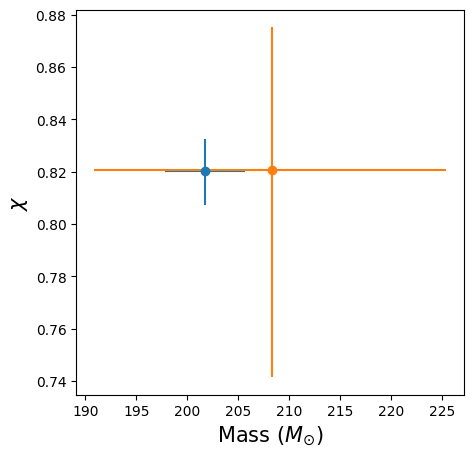

In [29]:
# 16th, 50th (median), 84th percentiles for each parameter
lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

f1_med = med[2]
f1_lo, f1_hi = lo[2], hi[2]

f2_med = med[6]
f2_lo, f2_hi = lo[6], hi[6]

tau1_med = med[3]
tau1_lo, tau1_hi = lo[3], hi[3]

tau2_med = med[7]
tau2_lo, tau2_hi = lo[7], hi[7]

# Switch if required
# 220 mode has the lower frequency = f2 so switch dynamically
if f2_med > f1_med:  
    f1_med, f2_med = f2_med, f1_med
    f1_lo,  f2_lo  = f2_lo,  f1_lo
    f1_hi,  f2_hi  = f2_hi,  f1_hi
    tau1_med, tau2_med = tau2_med, tau1_med
    tau1_lo,  tau2_lo  = tau2_lo,  tau1_lo
    tau1_hi,  tau2_hi  = tau2_hi,  tau1_hi

print("After: f2 is 220 so must be lower f")
print(f"f1_med = {f1_med:.1f} Hz")
print(f"f2_med = {f2_med:.1f} Hz")

# Calculate chi intercept for 330

omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

target_330 = 2 * np.pi * f1_med * tau1_med
lo_330 = 2 * np.pi * f1_lo * tau1_lo
hi_330 = 2 * np.pi * f1_hi * tau1_hi

# Find the argument of the target in the ratio using interpolation

chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

# Calculate chi intercept for 220
omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

target_220 = 2 * np.pi * f2_med * tau2_med
lo_220 = 2 * np.pi * f2_lo * tau2_lo
hi_220 = 2 * np.pi * f2_hi * tau2_hi

# Find the argument of the target in the ratio using interpolation

chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

# Calculate the masses
def convert_to_Msun(Mseconds):
    return Mseconds * 2.03e5

# Calculate Masses for 220 mode 
omega_hat_med_220, _, _ = mode_220(chi_med_220)
omega_hat_lo_220, _, _  = mode_220(chi_lo_220)
omega_hat_hi_220, _, _  = mode_220(chi_hi_220)

M_med_220 = omega_hat_med_220.real / (2 * np.pi * f2_med)
M_lo_220  = omega_hat_lo_220.real  / (2 * np.pi * f2_hi)
M_hi_220  = omega_hat_hi_220.real  / (2 * np.pi * f2_lo)

M_med_220 = convert_to_Msun(M_med_220)
M_lo_220  = convert_to_Msun(M_lo_220)
M_hi_220  = convert_to_Msun(M_hi_220)

# Calculate Masses for 330 mode
omega_hat_med_330, _, _ = mode_330(chi_med_330)
omega_hat_lo_330, _, _  = mode_330(chi_lo_330)
omega_hat_hi_330, _, _  = mode_330(chi_hi_330)

M_med_330 = omega_hat_med_330.real / (2 * np.pi * f1_med)
M_lo_330  = omega_hat_lo_330.real  / (2 * np.pi * f1_hi)
M_hi_330  = omega_hat_hi_330.real  / (2 * np.pi * f1_lo)

M_med_330 = convert_to_Msun(M_med_330)
M_lo_330  = convert_to_Msun(M_lo_330)
M_hi_330  = convert_to_Msun(M_hi_330)

# Print the results
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Mode", "χ (16th)", "χ (median)", "χ (84th)"]
table.add_row(["(2,2,0)", f"{chi_lo_220:.4f}", f"{chi_med_220:.4f}", f"{chi_hi_220:.4f}"])
table.add_row(["(3,3,0)", f"{chi_lo_330:.4f}", f"{chi_med_330:.4f}", f"{chi_hi_330:.4f}"])
print(table)

table = PrettyTable()
table.field_names = ["Mode", "M_low", "M_med", "M_high"]
table.add_row(["(2,2,0)", f"{M_lo_220:.2f}", f"{M_med_220:.2f}", f"{M_hi_220:.2f}"])
table.add_row(["(3,3,0)", f"{M_lo_330:.2f}", f"{M_med_330:.2f}", f"{M_hi_330:.2f}"])
print(table)

# Plot a little diagnostic plot
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(M_med_220, chi_med_220,
            xerr=[[M_med_220 - M_lo_220], [M_hi_220 - M_med_220]],
            yerr=[[chi_med_220 - chi_lo_220], [chi_hi_220 - chi_med_220]],
            marker='o')
ax.errorbar(M_med_330, chi_med_330,
            xerr=[[M_med_330 - M_lo_330], [M_hi_330 - M_med_330]],
            yerr=[[chi_med_330 - chi_lo_330], [chi_hi_330 - chi_med_330]],
            marker='o')
ax.set_ylabel("$\chi$", fontsize=15)
ax.set_xlabel("Mass ($M_{\odot}$)", fontsize=15)

- This lines up very niftily.
---

##### Method 2: As shown in lectures
- The method very briefly shown in the lectures takes a slightly different approach.
- It plots the Kerr modes, which are parameterised by $\chi$ in $\frac{M}{\tau}$-$Mf$ space.
- The sampled $f$ and $\tau$ are unconstrained in mass so they form a line in this plane. The intersection with the Kerr modes can then be used to calculate the M.
- The $\chi$ can be calculated similarly to method 1 by finding the $\chi$ value of the intersection point on the Kerr curve.

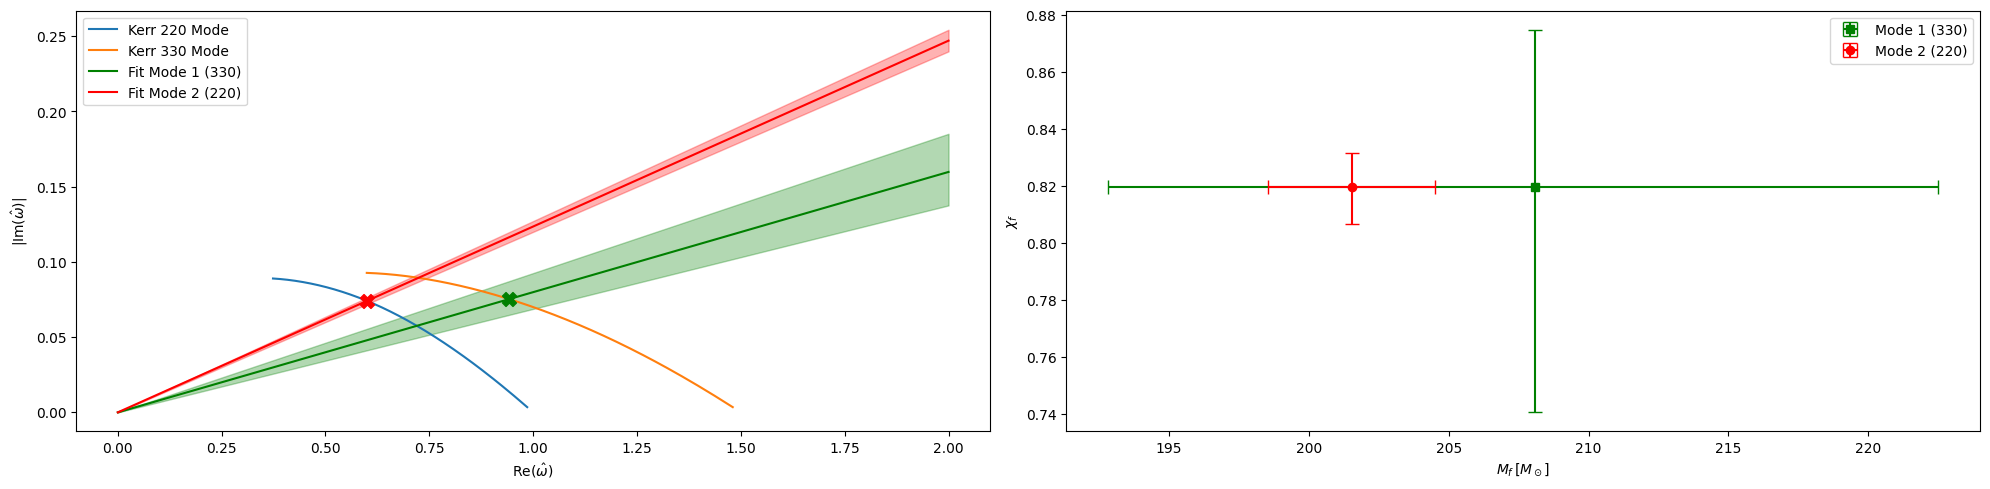

In [ ]:
# From the qnm extracted data
y220 = np.abs(omega_220.imag)
x220 = omega_220.real
y330 = np.abs(omega_330.imag)
x330 = omega_330.real

# Make gradients in the plane for each sampled pair 
def make_g(f, tau):
    return 1 / (2 * np.pi * f * tau)

g1_med = make_g(f1_med, tau1_med)
g1_lo  = make_g(f1_hi,  tau1_hi)
g1_hi  = make_g(f1_lo,  tau1_lo)
g2_med = make_g(f2_med, tau2_med)
g2_lo  = make_g(f2_hi,  tau2_hi)
g2_hi  = make_g(f2_lo,  tau2_lo)

# Create the linspace of the x axis to plot these lines
mf = np.linspace(0, 2, 1000)

# Find the crossings
Msun_s = 4.927e-6 # Natural unit conversion factor

def crossing(xk, yk, g):
    idx = np.where(np.diff(np.sign(yk - g * xk)))[0][0]
    return float(xk[idx]), float(yk[idx]), float(chi_values[idx])

def to_M(x_cross, f_hz): # Finds the mass from the Mf intersection
    return x_cross / (2 * np.pi * f_hz * Msun_s)

# Mode 1 (330) intersection and mass
# Intersections and uncertainties
x330_med, y330_c, chi330_med = crossing(x330, y330, g1_med)
x330_a,  _, chi330_a = crossing(x330, y330, g1_lo)
x330_b,  _, chi330_b = crossing(x330, y330, g1_hi)

# Converting the intersections to masses
M330_med = to_M(x330_med, f1_med) 
M330_a = to_M(x330_a, f1_med)
M330_b = to_M(x330_b, f1_med)

# Calculating the uncs
chi330_lo_err = chi330_med - min(chi330_a, chi330_b)
chi330_hi_err = max(chi330_a, chi330_b) - chi330_med
M330_lo_err  = M330_med - min(M330_a, M330_b)
M330_hi_err  = max(M330_a, M330_b) - M330_med

# Mode 2 (220) intersection and mass
# Intersections and uncertainties
x220_med, y220_c, chi220_med = crossing(x220, y220, g2_med)
x220_a, _, chi220_a = crossing(x220, y220, g2_lo)
x220_b, _, chi220_b = crossing(x220, y220, g2_hi)

# Converting to mass
M220_med = to_M(x220_med, f2_med)
M220_a = to_M(x220_a, f2_med)
M220_b = to_M(x220_b, f2_med)

# Uncertainties
chi220_lo_err = chi220_med - min(chi220_a, chi220_b)
chi220_hi_err = max(chi220_a, chi220_b) - chi220_med
M220_lo_err  = M220_med - min(M220_a, M220_b)
M220_hi_err  = max(M220_a, M220_b) - M220_med

# Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

ax[0].set_xlabel(r"$\mathrm{Re}(\hat{\omega})$")
ax[0].set_ylabel(r"$|\mathrm{Im}(\hat{\omega})|$")
ax[0].plot(x220, y220, label='Kerr 220 Mode')
ax[0].plot(x330, y330, label='Kerr 330 Mode')

c1, c2 = 'green', 'red'
ax[0].plot(mf, g1_med * mf, color=c1, label='Fit Mode 1 (330)')
ax[0].fill_between(mf, g1_lo * mf, g1_hi * mf, color=c1, alpha=0.3)
ax[0].plot(mf, g2_med * mf, color=c2, label='Fit Mode 2 (220)')
ax[0].fill_between(mf, g2_lo * mf, g2_hi * mf, color=c2, alpha=0.3)
ax[0].legend()

ax[0].scatter(x330_med, y330_c, s=100, marker='X', color=c1, zorder=5)
ax[0].scatter(x220_med, y220_c, s=100, marker='X', color=c2, zorder=5)

ax[1].set_xlabel(r"$M_f \, [M_\odot]$")
ax[1].set_ylabel(r"$\chi_f$")

ax[1].errorbar(
    M330_med, chi330_med,
    xerr=[[M330_lo_err], [M330_hi_err]],
    yerr=[[chi330_lo_err], [chi330_hi_err]],
    fmt='s', color=c1, capsize=5, label='Mode 1 (330)'
)
ax[1].errorbar(
    M220_med, chi220_med,
    xerr=[[M220_lo_err], [M220_hi_err]],
    yerr=[[chi220_lo_err], [chi220_hi_err]],
    fmt='o', color=c2, capsize=5, label='Mode 2 (220)'
)

ax[1].legend()
plt.tight_layout()
plt.show()

- The uncertainties do not full overlap with the other mode's median values. We should try doing magic with the posterior samples to see the confidence intervals.

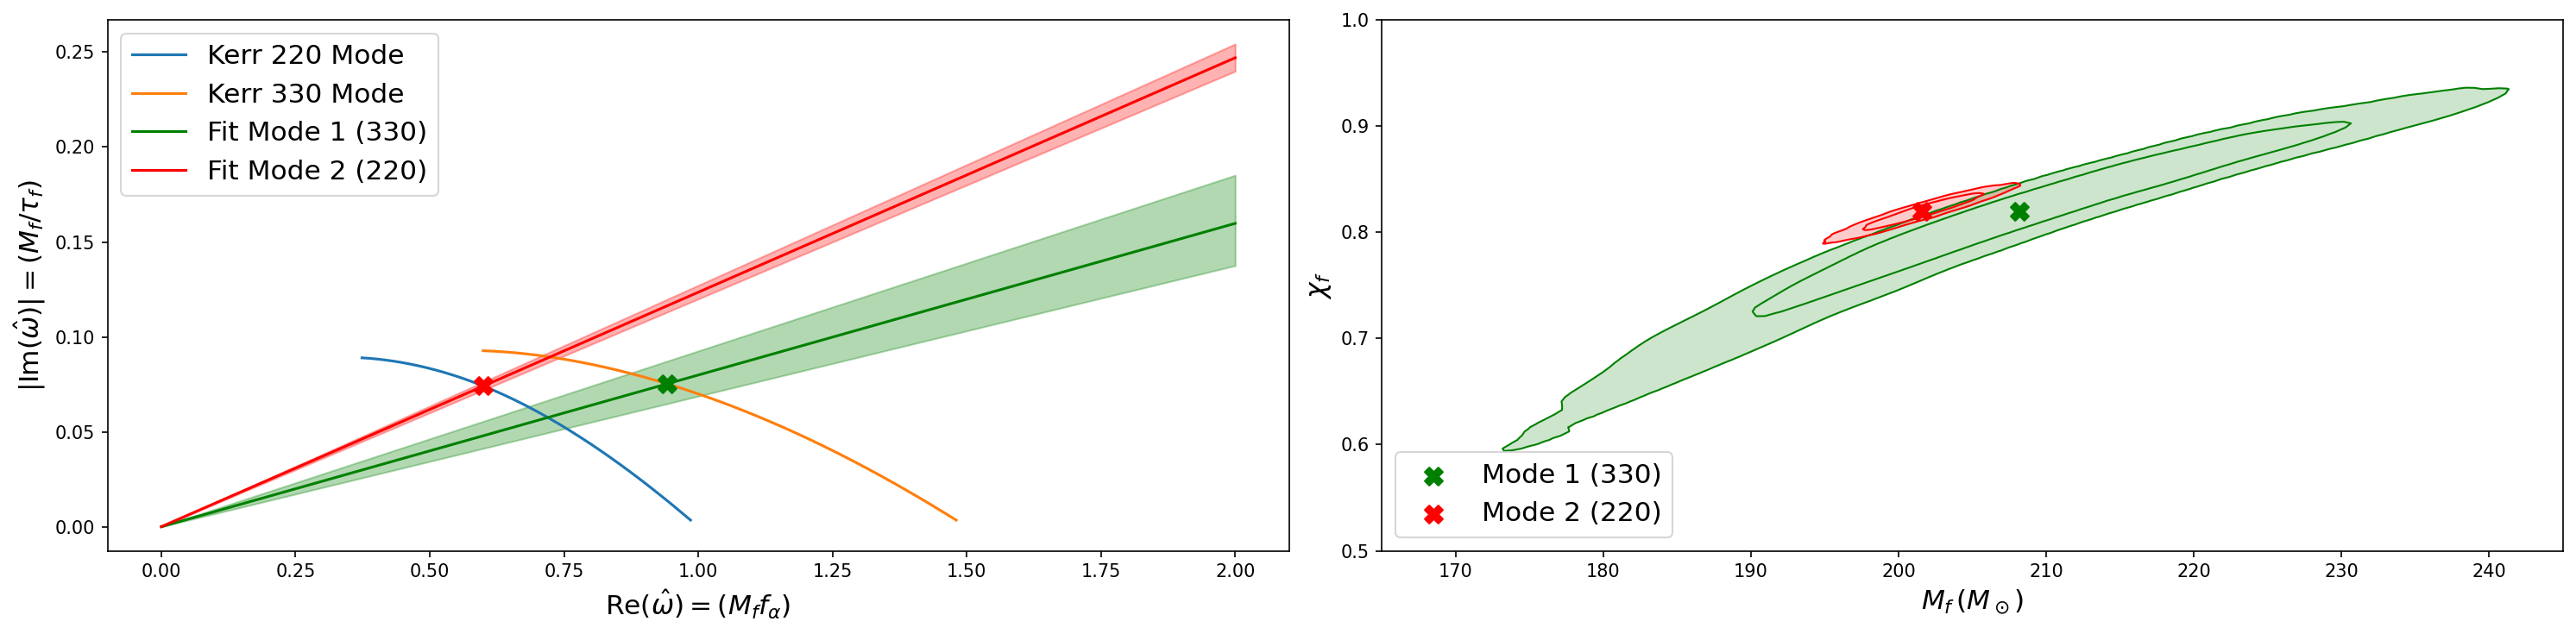

In [34]:
from scipy.stats import gaussian_kde

# Per-sample swap: 
# f1/tau1 = 330 (higher freq)
# f2/tau2 = 220 (lower)
swap   = samples[:, 6] > samples[:, 2]
f1_s   = np.where(swap, samples[:, 6], samples[:, 2])
tau1_s = np.where(swap, samples[:, 7], samples[:, 3])
f2_s   = np.where(swap, samples[:, 2], samples[:, 6])
tau2_s = np.where(swap, samples[:, 3], samples[:, 7])

# There is not always a crossing if something is GR inconsistent
M330_s, chi330_s, M220_s, chi220_s = [], [], [], []
for f1i, t1i, f2i, t2i in zip(f1_s, tau1_s, f2_s, tau2_s):
    try:
        xc, _, chi_c = crossing(x330, y330, make_g(f1i, t1i))
        M330_s.append(to_M(xc, f1i)); chi330_s.append(chi_c)
    except IndexError: pass
    try:
        xc, _, chi_c = crossing(x220, y220, make_g(f2i, t2i))
        M220_s.append(to_M(xc, f2i)); chi220_s.append(chi_c)
    except IndexError: pass

M330_s, chi330_s = np.array(M330_s), np.array(chi330_s)
M220_s, chi220_s = np.array(M220_s), np.array(chi220_s)

# KDE helper
def plot_kde_contours(ax, M_s, chi_s, color):
    # Build density estimat
    kde = gaussian_kde(np.vstack([M_s, chi_s]))
    # Eval density estimat over grid
    gx = np.linspace(M_s.min(), M_s.max(), 200)
    gy = np.linspace(chi_s.min(), chi_s.max(), 200)
    X, Y = np.meshgrid(gx, gy)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    # Find density threshold
    z_sorted = np.sort(Z.ravel())[::-1]
    cumsum = np.cumsum(z_sorted) / z_sorted.sum()
    t68 = z_sorted[np.searchsorted(cumsum, 0.68)]
    t95 = z_sorted[np.searchsorted(cumsum, 0.95)]
    ax.contourf(X, Y, Z, levels=[t95, t68, Z.max()], colors=[color, color], alpha=0.2)
    ax.contour(X, Y, Z, levels=[t95, t68], colors=[color], linewidths=1)

# Plot
c1, c2 = 'green', 'red'

g1_med = make_g(f1_med, tau1_med)
g1_lo = make_g(f1_hi, tau1_hi)
g1_hi = make_g(f1_lo, tau1_lo)
g2_med = make_g(f2_med, tau2_med)
g2_lo = make_g(f2_hi, tau2_hi)
g2_hi = make_g(f2_lo, tau2_lo)

mf = np.linspace(0, 2, 1000)

fig, ax = plt.subplots(1, 2, figsize=(20, 5), dpi=150)

ax[0].set_xlabel(r"$\mathrm{Re}(\hat{\omega}) = (M_ff_\alpha)$",fontsize=15)
ax[0].set_ylabel(r"$|\mathrm{Im}(\hat{\omega})| = (M_f/\tau_f)$",fontsize=15)
ax[0].plot(x220, y220, label='Kerr 220 Mode')
ax[0].plot(x330, y330, label='Kerr 330 Mode')
ax[0].plot(mf, g1_med * mf, color=c1, label='Fit Mode 1 (330)')
ax[0].fill_between(mf, g1_lo * mf, g1_hi * mf, color=c1, alpha=0.3)
ax[0].plot(mf, g2_med * mf, color=c2, label='Fit Mode 2 (220)')
ax[0].fill_between(mf, g2_lo * mf, g2_hi * mf, color=c2, alpha=0.3)
x330_med, y330_c, _ = crossing(x330, y330, g1_med)
x220_med, y220_c, _ = crossing(x220, y220, g2_med)
ax[0].scatter(x330_med, y330_c, s=100, marker='X', color=c1, zorder=5)
ax[0].scatter(x220_med, y220_c, s=100, marker='X', color=c2, zorder=5)
ax[0].legend(fontsize=15)

ax[1].set_xlabel(r"$M_f \, (M_\odot)$",fontsize=15)
ax[1].set_ylabel(r"$\chi_f$",fontsize=15)
plot_kde_contours(ax[1], M330_s, chi330_s, c1)
plot_kde_contours(ax[1], M220_s, chi220_s, c2)
ax[1].scatter(np.median(M330_s), np.median(chi330_s), s=100, marker='X', color=c1, zorder=5, label='Mode 1 (330)')
ax[1].scatter(np.median(M220_s), np.median(chi220_s), s=100, marker='X', color=c2, zorder=5, label='Mode 2 (220)')
ax[1].legend(fontsize=15, loc='lower left')
ax[1].set_xlim(165,245)
ax[1].set_ylim(0.5,1)

plt.tight_layout()
plt.show()

- The overlap is not very considerable. This means we have weak evidence for the consistency.

## Justifying $t_0$

- We can justify our choice of t0 using this analysis.
- By running the analysis repeatedly at slight t0 deviations, we can choose a t0 at the start of a stable plateau.
- Too early, the 2-mode assumption will be wrong.
- Too late, the SNR will get too low.

In [35]:
def run_analysis(t0):
    #---
    def lnL(theta):
        A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
        t = t_ring
        model = (A1 * np.cos(2*np.pi*f1*(t - t0) + phi1) * np.exp(-(t - t0)/tau1) +
                A2 * np.cos(2*np.pi*f2*(t - t0) + phi2) * np.exp(-(t - t0)/tau2))
        residuals = d_ring - model  # d is your on-source data, t > t0
        return -0.5 * np.sum(residuals**2 / off_std**2)

    t_on = t[(t > on_time_start) & (t < on_time_end)]
    d_on = strain[(t > on_time_start) & (t < on_time_end)]

    t_off_1 = t[(t < on_time_start)]
    d_off_1 = strain[(t < on_time_start)]

    t_off_2 = t[(t > on_time_end)]
    d_off_2 = strain[(t > on_time_end)]

    t_ring = t_on[t_on > t0]
    d_ring = d_on[t_on > t0]

    #---

    np.random.seed(1701)

    sampler = dynesty.DynamicNestedSampler(
        lnL,
        prior_transform,
        ndim=8,
        bound='multi',    # multiellipsoid bounding (good default)
        sample='rwalk'    # random walk sampling
    )

    sampler.run_nested(print_progress=True)

    results = sampler.results

    # Resample to equal weights (important — dynesty samples are not equal weight)
    weights = np.exp(results.logwt - results.logz[-1])
    samples = dyfunc.resample_equal(results.samples, weights)

    # samples has shape (N, 8)
    # columns match your parameter order: A1, phi1, f1, tau1, A2, phi2, f2, tau2
    A1, phi1, f1, tau1 = samples[:,0], samples[:,1], samples[:,2], samples[:,3]
    A2, phi2, f2, tau2 = samples[:,4], samples[:,5], samples[:,6], samples[:,7]

    labels = [r"$A_1$", r"$\phi_1$", r"$f_1$", r"$\tau_1$",
            r"$A_2$", r"$\phi_2$", r"$f_2$", r"$\tau_2$"]

    fig = corner.corner(
        samples,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],  # 1-sigma credible intervals
        show_titles=True,
        title_fmt=".2e",
    )

    # 16th, 50th (median), 84th percentiles for each parameter
    lo, med, hi = np.percentile(samples, [16, 50, 84], axis=0)

    f1_med = med[2]
    f1_lo, f1_hi = lo[2], hi[2]

    f2_med = med[6]
    f2_lo, f2_hi = lo[6], hi[6]

    tau1_med = med[3]
    tau1_lo, tau1_hi = lo[3], hi[3]

    tau2_med = med[7]
    tau2_lo, tau2_hi = lo[7], hi[7]

    # Ensure f1/tau1 = 330 (higher freq), f2/tau2 = 220 (lower freq)
    if f2_med > f1_med:
        f1_med, f2_med = f2_med, f1_med
        f1_lo,  f2_lo  = f2_lo,  f1_lo
        f1_hi,  f2_hi  = f2_hi,  f1_hi
        tau1_med, tau2_med = tau2_med, tau1_med
        tau1_lo,  tau2_lo  = tau2_lo,  tau1_lo
        tau1_hi,  tau2_hi  = tau2_hi,  tau1_hi

    omega_220_ratio = omega_220.real / np.abs(omega_220.imag)

    target_220 = 2 * np.pi * f2_med * tau2_med
    lo_220 = 2 * np.pi * f2_lo * tau2_lo
    hi_220 = 2 * np.pi * f2_hi * tau2_hi

    chi_med_220 = np.interp(target_220, omega_220_ratio, chi_values)
    chi_lo_220  = np.interp(lo_220, omega_220_ratio, chi_values)
    chi_hi_220  = np.interp(hi_220, omega_220_ratio, chi_values)

    omega_330_ratio = omega_330.real / np.abs(omega_330.imag)

    target_330 = 2 * np.pi * f1_med * tau1_med
    lo_330 = 2 * np.pi * f1_lo * tau1_lo
    hi_330 = 2 * np.pi * f1_hi * tau1_hi

    chi_med_330 = np.interp(target_330, omega_330_ratio, chi_values)
    chi_lo_330  = np.interp(lo_330, omega_330_ratio, chi_values)
    chi_hi_330  = np.interp(hi_330, omega_330_ratio, chi_values)

    # Calculate Masses for 220 mode (uses f2)
    omega_hat_med_220, _, _ = mode_220(chi_med_220)
    omega_hat_lo_220, _, _  = mode_220(chi_lo_220)
    omega_hat_hi_220, _, _  = mode_220(chi_hi_220)

    M_med_220 = omega_hat_med_220.real / (2 * np.pi * f2_med)
    M_lo_220  = omega_hat_lo_220.real  / (2 * np.pi * f2_hi)
    M_hi_220  = omega_hat_hi_220.real  / (2 * np.pi * f2_lo)

    M_med_220 = convert_to_Msun(M_med_220)
    M_lo_220  = convert_to_Msun(M_lo_220)
    M_hi_220  = convert_to_Msun(M_hi_220)

    # Calculate Masses for 330 mode (uses f1)
    omega_hat_med_330, _, _ = mode_330(chi_med_330)
    omega_hat_lo_330, _, _  = mode_330(chi_lo_330)
    omega_hat_hi_330, _, _  = mode_330(chi_hi_330)

    M_med_330 = omega_hat_med_330.real / (2 * np.pi * f1_med)
    M_lo_330  = omega_hat_lo_330.real  / (2 * np.pi * f1_hi)
    M_hi_330  = omega_hat_hi_330.real  / (2 * np.pi * f1_lo)

    M_med_330 = convert_to_Msun(M_med_330)
    M_lo_330  = convert_to_Msun(M_lo_330)
    M_hi_330  = convert_to_Msun(M_hi_330)

    return (f1_med, f1_lo, f1_hi), (f2_med, f2_lo, f2_hi), (tau1_med, tau1_lo, tau1_hi), (tau2_med, tau2_lo, tau2_hi), (M_med_220, M_lo_220, M_hi_220), (M_med_330, M_lo_330, M_hi_330)


In [44]:
# Plateau test

# Define the t0 values to test
t0_offsets_ms = np.linspace(-15, 15, 50)
t0_values = t0 + t0_offsets_ms * 1e-3

def process_samples(samp):
    s = samp.copy()
    swap = s[:, 6] > s[:, 2]
    f1   = np.where(swap, s[:, 6], s[:, 2])
    tau1 = np.where(swap, s[:, 7], s[:, 3])
    f2   = np.where(swap, s[:, 2], s[:, 6])
    tau2 = np.where(swap, s[:, 3], s[:, 7])

    pct = [5, 25, 50, 75, 95]
    return {k: np.percentile(v, pct) for k, v in [
        ('f1', f1), ('tau1', tau1), ('f2', f2), ('tau2', tau2),
    ]}

# Run sampler at each t0
plateau_results = []
for t0_val in t0_values:
    t_ring_loc = t_on[t_on > t0_val]
    d_ring_loc = d_on[t_on > t0_val]
    print(f"t0 = {t0_val:.5f}  ({len(t_ring_loc)} datapoints)", flush=True)

    def _lnL(theta, _t=t_ring_loc, _d=d_ring_loc, _t0=t0_val):
        A1, phi1, f1, tau1, A2, phi2, f2, tau2 = theta
        dt = _t - _t0
        m = (A1 * np.cos(2*np.pi*f1*dt + phi1) * np.exp(-dt/tau1) +
             A2 * np.cos(2*np.pi*f2*dt + phi2) * np.exp(-dt/tau2))
        return -0.5 * np.sum((_d - m)**2 / off_std**2)

    np.random.seed(1701)
    sampler = dynesty.DynamicNestedSampler(
        _lnL, prior_transform, ndim=8, bound='multi', sample='rwalk'
    )
    sampler.run_nested(print_progress=True)
    w    = np.exp(sampler.results.logwt - sampler.results.logz[-1])
    samp = dyfunc.resample_equal(sampler.results.samples, w)
    plateau_results.append(process_samples(samp))



t0 = 13.99706  (422 datapoints)


32173it [02:22, 226.26it/s, batch: 4 | bound: 7 | nc: 1 | ncall: 840002 | eff(%):  3.770 | loglstar: -390.971 < -383.939 < -386.148 | logz: -431.120 +/-  0.233 | stop:  0.969]            


t0 = 13.99767  (419 datapoints)


31148it [02:13, 233.17it/s, batch: 4 | bound: 6 | nc: 1 | ncall: 812562 | eff(%):  3.771 | loglstar: -389.935 < -383.049 < -384.784 | logz: -427.347 +/-  0.225 | stop:  0.940]            


t0 = 13.99829  (417 datapoints)


...

24117it [02:08, 186.99it/s, batch: 5 | bound: 1 | nc: 1 | ncall: 614862 | eff(%):  3.838 | loglstar: -154.308 < -147.875 < -153.819 | logz: -177.578 +/-  0.166 | stop:  0.979]        


t0 = 14.02645  (301 datapoints)


25693it [02:21, 182.18it/s, batch: 6 | bound: 7 | nc: 1 | ncall: 661517 | eff(%):  3.806 | loglstar: -153.895 < -146.135 < -147.469 | logz: -173.030 +/-  0.152 | stop:  0.742]        


t0 = 14.02706  (299 datapoints)


26585it [02:25, 182.73it/s, batch: 4 | bound: 7 | nc: 1 | ncall: 685342 | eff(%):  3.804 | loglstar: -152.464 < -144.254 < -145.950 | logz: -177.526 +/-  0.193 | stop:  0.751]        


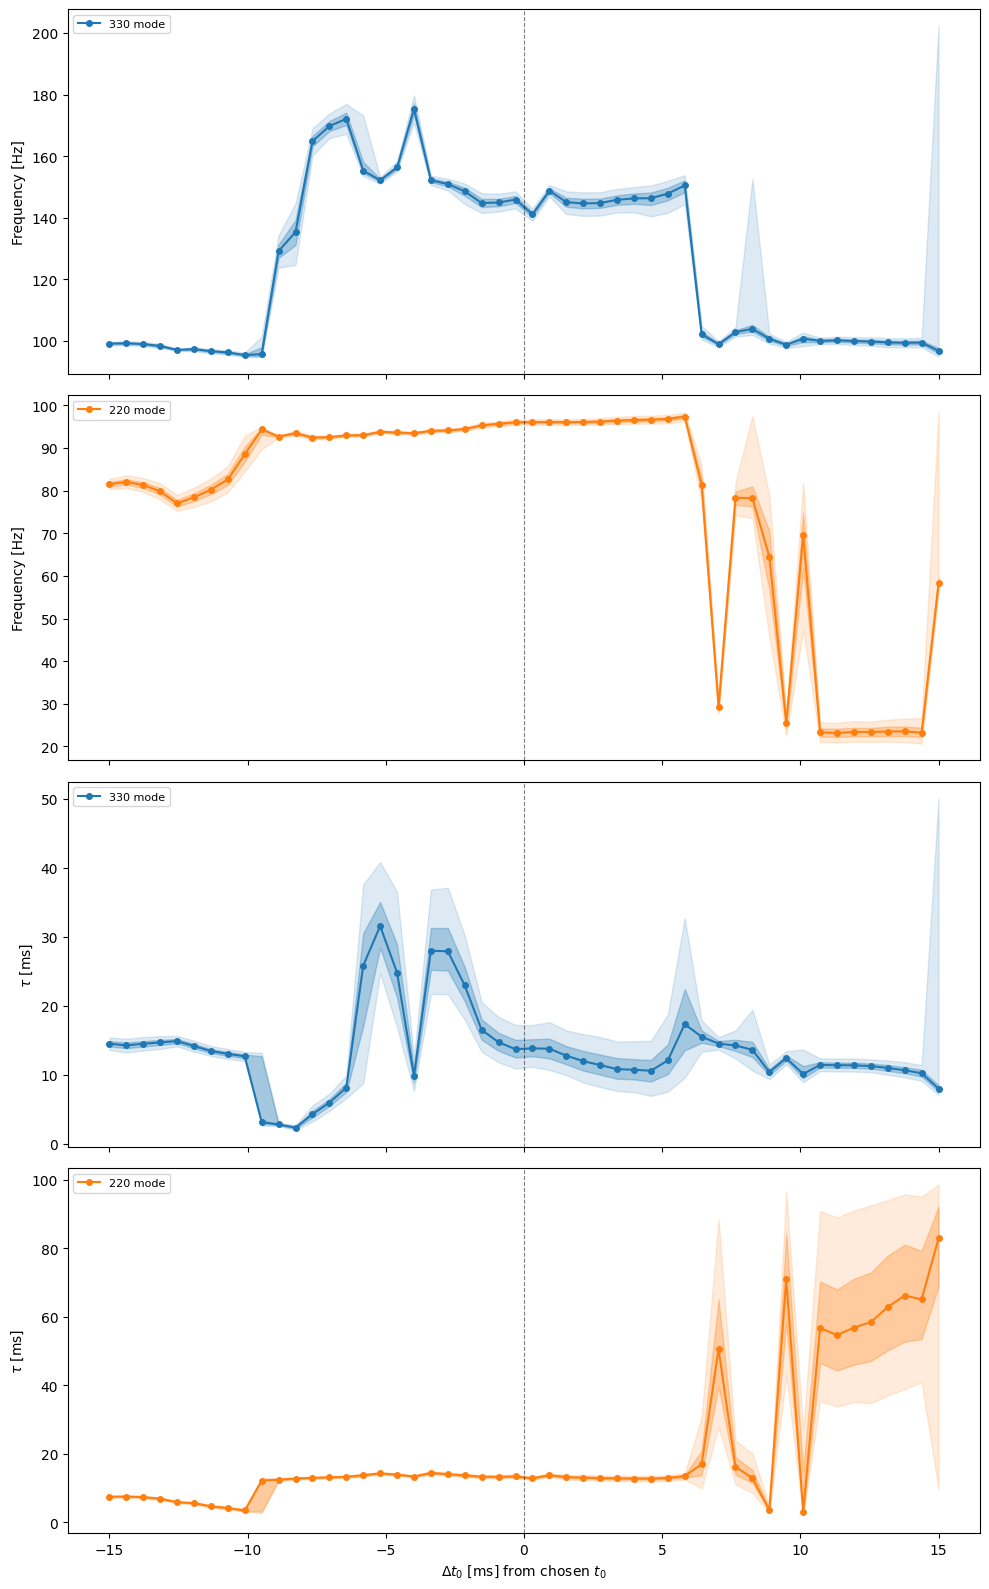

In [ ]:
# Plot
def _collect(key):
    return np.array([r[key] for r in plateau_results])  # (n_t0, 5)

def _band(ax, x, data, color, label=None):
    """data columns: 5th, 25th, 50th, 75th, 95th percentile."""
    ax.fill_between(x, data[:, 0], data[:, 4], color=color, alpha=0.15)
    ax.fill_between(x, data[:, 1], data[:, 3], color=color, alpha=0.30)
    ax.plot(x, data[:, 2], color=color, marker='o', ms=4, label=label)

x = t0_offsets_ms
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

_band(axes[0], x, _collect('f1'),          'C0', '330 mode')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].legend(fontsize=8)

_band(axes[1], x, _collect('f2'),          'C1', '220 mode')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].legend(fontsize=8)

_band(axes[2], x, _collect('tau1') * 1e3, 'C0', '330 mode')
axes[2].set_ylabel(r'$\tau$ [ms]')
axes[2].legend(fontsize=8)

_band(axes[3], x, _collect('tau2') * 1e3, 'C1', '220 mode')
axes[3].set_ylabel(r'$\tau$ [ms]')
axes[3].legend(fontsize=8)

for ax in axes.flat:
    ax.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
axes[-1].set_xlabel(r'$\Delta t_0$ [ms] from chosen $t_0$')

plt.tight_layout()
plt.show()